In [1]:
%matplotlib widget

In [2]:
from huggingface_hub import snapshot_download

# Specify the mission you want to download.
mission = "2024-11-02-17-18-32"

# Download the full dataset
allow_patterns = [f"*"]

# Download all data from a single mission
allow_patterns = [f"{mission}/*"]

# Download a specific topic
# topic = "alphasense_front_center"
# allow_patterns = [f"{mission}/*{topic}*", f"{mission}/*.yaml"]


# to only include a subset of the 

# If this is interuppted during download, simply re-run the block and huggingface_hub will resume the download without re-downloading the already downloaded files.
hugging_face_data_cache_path = snapshot_download(repo_id="leggedrobotics/grand_tour_dataset", allow_patterns=allow_patterns, repo_type="dataset")

Fetching ... files: 0it [00:00, ?it/s]

In [3]:
from pathlib import Path

dataset_folder = Path("~/ARCADIA Summer 2026/testing/grand_tour_dataset").expanduser()
dataset_folder.mkdir(parents=True, exist_ok=True)

print(f"Data will be extracted to: {dataset_folder}")

Data will be extracted to: C:\Users\arianna\ARCADIA Summer 2026\testing\grand_tour_dataset


In [4]:
import tarfile
import zarr
from pathlib import Path

cache_data = Path("C:/Users/arianna/.cache/huggingface/hub/datasets--leggedrobotics--grand_tour_dataset/snapshots/daf91c5e2b6db564822a35cc58222d73f8e75bab/2024-11-02-17-18-32/data")

dest_data = Path("~/ARCADIA Summer 2026/testing/grand_tour_dataset/2024-11-02-17-18-32/data").expanduser()
dest_data.mkdir(parents=True, exist_ok=True)

# Copy .zgroup first
import shutil
shutil.copy2(cache_data / ".zgroup", dest_data / ".zgroup")

# Extract each tar into dest_data
for tar_path in sorted(cache_data.glob("*.tar")):
    print(f"Extracting {tar_path.name}...")
    with tarfile.open(tar_path, "r") as tar:
        tar.extractall(path=dest_data)

print("Done.")

Extracting adis_imu.tar...
Extracting alphasense_front_center.tar...
Extracting alphasense_front_left.tar...
Extracting alphasense_front_right.tar...
Extracting alphasense_imu.tar...
Extracting alphasense_left.tar...
Extracting alphasense_right.tar...
Extracting anymal_command_twist.tar...
Extracting anymal_imu.tar...
Extracting anymal_state_actuator.tar...
Extracting anymal_state_battery.tar...
Extracting anymal_state_odometry.tar...
Extracting anymal_state_state_estimator.tar...
Extracting ap20_imu.tar...
Extracting cpt7_ie_rt_odometry.tar...
Extracting cpt7_ie_rt_tf.tar...
Extracting cpt7_ie_tc_odometry.tar...
Extracting cpt7_ie_tc_tf.tar...
Extracting depth_camera_front_lower.tar...
Extracting depth_camera_front_upper.tar...
Extracting depth_camera_left.tar...
Extracting depth_camera_rear_lower.tar...
Extracting depth_camera_rear_upper.tar...
Extracting depth_camera_right.tar...
Extracting dlio_hesai_points_undistorted.tar...
Extracting dlio_map_odometry.tar...
Extracting dlio_tf.t

In [5]:
import os
import zarr

# Remove the stray v3 metadata file
zarr_json = dest_data / "zarr.json"
if zarr_json.exists():
    os.remove(zarr_json)
    print("Removed zarr.json")

# Open explicitly as zarr v2
root = zarr.open_group(str(dest_data), mode='r', zarr_format=2)
print(list(root.keys()))

['adis_imu', 'alphasense_front_center', 'alphasense_front_left', 'alphasense_imu', 'alphasense_front_right', 'alphasense_right', 'alphasense_left', 'anymal_command_twist', 'anymal_imu', 'anymal_state_actuator', 'anymal_state_battery', 'anymal_state_odometry', 'anymal_state_state_estimator', 'cpt7_ie_rt_odometry', 'ap20_imu', 'cpt7_ie_rt_tf', 'cpt7_ie_tc_odometry', 'cpt7_ie_tc_tf', 'depth_camera_front_lower', 'depth_camera_left', 'depth_camera_rear_lower', 'depth_camera_front_upper', 'depth_camera_rear_upper', 'dlio_hesai_points_undistorted', 'depth_camera_right', 'dlio_tf', 'dlio_map_odometry', 'gnss_raw_cpt7_ie_tc', 'hdr_left', 'gnss_raw_cpt7_ie_rt', 'hdr_front', 'hdr_right', 'hesai_points', 'hesai_points_undistorted', 'livox_imu', 'livox_points_undistorted', 'livox_points', 'navsatfix_cpt7_ie_tc', 'velodyne_points', 'zed2i_depth_confidence_image', 'velodyne_points_undistorted', 'stim320_imu', 'tf', 'zed2i_depth_image', 'zed2i_right_images', 'zed2i_left_images', 'zed2i_vio_map']


In [6]:
def load_extrinsics(root):
    """
    Pull static transforms from the tf zarr group.
    Returns dict of {(parent_frame, child_frame): 4x4 np.ndarray}
    """
    tf_group = root["tf"]
    transforms = {}
    
    parent_frames = tf_group["header_frame_id"][:]   # e.g. b"base_link"
    child_frames  = tf_group["child_frame_id"][:]
    positions     = tf_group["transform_pos"][:]     # (N, 3)
    orientations  = tf_group["transform_orien"][:]   # (N, 4) xyzw
    timestamps    = tf_group["timestamp"][:]
    
    # For static transforms, just take the first occurrence of each pair
    seen = set()
    for i, (p, c) in enumerate(zip(parent_frames, child_frames)):
        key = (p.decode(), c.decode())
        if key not in seen:
            seen.add(key)
            transforms[key] = quat_to_matrix(positions[i], orientations[i])
    
    return transforms

"""
# T_camera_lidar: points in LiDAR frame → camera frame
T_body_lidar   = extrinsics[("base_link", "hesai_lidar")]
T_body_cam     = extrinsics[("base_link", "alphasense_front_center")]
T_camera_lidar = np.linalg.inv(T_body_cam) @ T_body_lidar
"""

'\n# T_camera_lidar: points in LiDAR frame → camera frame\nT_body_lidar   = extrinsics[("base_link", "hesai_lidar")]\nT_body_cam     = extrinsics[("base_link", "alphasense_front_center")]\nT_camera_lidar = np.linalg.inv(T_body_cam) @ T_body_lidar\n'

In [7]:
from __future__ import annotations
 
import logging
import math
import time
import uuid
from collections import defaultdict
from collections import deque
from dataclasses import dataclass, field
from typing import Optional
import matplotlib.pyplot as plt
import networkx as nx
import umap
from PIL import Image
 
import numpy as np

from tqdm import tqdm

import sys

# import sam3
# import torch
from google import genai

HF_TOKEN = os.getenv("HF_TOKEN")
# GEMINI_API_KEY = os.getenv("GEMINI_API_KEY")
GEMINI_API_KEY = "AQ.Ab8RN6KYmST55DqSimSVYpNBNTPibPBieE6vHTOw0IoRxAOVpQ"

if not GEMINI_API_KEY:
    raise RuntimeError("Missing GEMINI_API_KEY in environment variables")

client = genai.Client(api_key=GEMINI_API_KEY)
 
# ── FAISS ──────────────────────────────────────────────────────────────────────
try:
    import faiss
    FAISS_AVAILABLE = True
except ImportError:
    FAISS_AVAILABLE = False
    logging.warning("faiss-cpu not found. Run: pip install faiss-cpu")
 
# ── CLIP backend ───────────────────────────────────────────────────────────────
# Prefer open_clip; fall back to HuggingFace transformers; then mock.
try:
    import open_clip
    import torch
    CLIP_BACKEND = "open_clip"
except ImportError:
    try:
        from transformers import CLIPModel, CLIPProcessor
        import torch
        CLIP_BACKEND = "transformers"
    except ImportError:
        CLIP_BACKEND = "mock"
        logging.warning(
            "No CLIP backend found — using deterministic mock embeddings.\n"
            "For real embeddings: pip install open_clip_torch"
        )
 
logging.basicConfig(level=logging.INFO, format="%(levelname)s  %(name)s  %(message)s")

# ── SAM3 ──────────────────────────────────────────────────────────────────────
# IMPLEMENT HERE ONCE YOU CAN

# ── YOLO ──────────────────────────────────────────────────────────────────────
from ultralytics import YOLO

model = YOLO("yolov8s-seg.pt")

CLASS_SIM_THRESHOLDS = {
    "person":       0.62,   # lower — high intra-class variance
    "backpack":     0.70,
    "car":          0.75,
    "traffic light": 0.75,  # distinctive, should be strict
    "default":      0.72,
}
    
CLASS_SPATIAL_THRESHOLDS = {
    "person":   1.5,   # people move; wider gate
    "default":  1,
}

In [8]:
@dataclass
class ObservationRecord:
    """
    One robot's observation of one entity segment at one moment.
 
    Written once, never mutated. The embedding is L2-normalised so
    inner product == cosine similarity in the FAISS index.
    """
    obs_id:             str                     # unique observation ID
    entity_id:          str                     # global entity (assigned after dedup)
    agent_id:           str                     # which robot
    timestamp:          float                   # wall-clock seconds
    embedding:          np.ndarray              # CLIP vec, shape (D,), float32, unit-norm
    pose_3d:            tuple[float, float, float]  # (x, y, z) in world frame, metres
    label_distribution: dict[str, float]        # {label: probability}, sums to 1
    confidence:         float                   # overall observation confidence [0, 1]
    bounding_box:       Optional[tuple] = None  # (x1,y1,x2,y2) in image pixels
    reid_embedding:     Optional[np.ndarray] = None # FastReID vector
 
@dataclass
class EntityState:
    """
    Current consensus state for a tracked entity, computed on demand.
 
    High embedding_variance → agents disagree on what the entity looks like.
    High pose_uncertainty   → agents disagree on where it is.
    is_conflicted           → top two labels are within 20 % of each other.
    """
    entity_id:           str
    consensus_label:     str
    label_distribution:  dict[str, float]   # merged across all agents
    consensus_pose:      np.ndarray         # weighted-mean 3D position
    pose_uncertainty:    float              # RMS deviation from mean pose, metres
    embedding_centroid:  np.ndarray         # mean unit-norm embedding
    embedding_variance:  float              # mean cosine distance from centroid
    confidence:          float              # composite score [0, 1]
    witness_count:       int                # distinct agents that observed this entity
    first_seen:          float              # earliest timestamp
    last_seen:           float              # most recent timestamp
    observations:        list[str]          # obs_ids contributing to this state
    is_conflicted:       bool               # True when top labels are nearly tied
 
 
@dataclass
class QueryResult:
    """Single result from a text or spatial query."""
    observation:    ObservationRecord
    similarity:     float                    # cosine similarity to query (or proximity score)
    entity_state:   Optional[EntityState]    # None if entity not yet computed

In [9]:
# ══════════════════════════════════════════════════════════════════════════════
# CLIP EMBEDDER
# ══════════════════════════════════════════════════════════════════════════════
 
class CLIPEmbedder:
    """
    Thin wrapper around a CLIP model that returns L2-normalised float32 vectors.
 
    Supports three backends:
        open_clip   — preferred, open-source, fast
        transformers — HuggingFace fallback
        mock        — deterministic random vectors for testing without GPU/model
 
    All backends produce 512-dim vectors (ViT-B/32 default).
    Swap model_name for larger models (ViT-L-14 → 768-dim; update embedding_dim).
    """
 
    def __init__(
        self,
        model_name:  str = "ViT-B-32",
        pretrained:  str = "openai",
        device:      str = "cpu",
    ):
        self.model_name = model_name
        self.device     = device
        self.dim        = 512          # ViT-B/32 output dimension
        self._model     = None
        self._log       = logging.getLogger("CLIPEmbedder")
        self._setup(pretrained)
 
    # ── Setup ──────────────────────────────────────────────────────────────────
 
    def _setup(self, pretrained: str) -> None:
        if CLIP_BACKEND == "open_clip":
            try:
                self._log.info(f"Loading open_clip {self.model_name} ({pretrained})")
                self._model, _, self._preprocess = open_clip.create_model_and_transforms(
                    self.model_name, pretrained=pretrained, device=self.device
                )
                self._tokenizer = open_clip.get_tokenizer(self.model_name)
                self._model.eval()
                # Infer actual output dimension from the model
                with torch.no_grad():
                    dummy = self._tokenizer(["test"]).to(self.device)
                    self.dim = int(self._model.encode_text(dummy).shape[-1])
                return
            except Exception as e:
                self._log.warning(
                    f"open_clip model load failed ({e}). "
                    "Falling back to mock embedder. "
                    "On a connected machine this resolves automatically."
                )
                self._model = None
 
        if CLIP_BACKEND == "transformers":
            try:
                from huggingface_hub import login
                login(token=os.environ["HF_TOKEN"])
                self._log.info("Loading HuggingFace CLIP (openai/clip-vit-base-patch32)")
                self._model     = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
                self._processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")
                self.dim = 512
                return
            except Exception as e:
                self._log.warning(f"transformers CLIP load failed ({e}). Using mock embedder.")
                self._model = None
 
        self._log.warning(
            "Mock embedder active — deterministic random vectors used in place of CLIP. "
            "Install open_clip_torch and ensure network access to enable real embeddings."
        )
 
    # ── Public API ─────────────────────────────────────────────────────────────
 
    def embed_text(self, text: str) -> np.ndarray:
        """
        Embed a text string into CLIP feature space.
        Returns a float32 unit-norm vector of shape (dim,).
        """
        if CLIP_BACKEND == "open_clip" and self._model is not None:
            tokens = self._tokenizer([text]).to(self.device)
            with torch.no_grad():
                feat = self._model.encode_text(tokens)
            return self._to_unit_np(feat)
 
        if CLIP_BACKEND == "transformers" and self._model is not None:
            inputs = self._processor(text=[text], return_tensors="pt", padding=True)
            with torch.no_grad():
                feat = self._model.get_text_features(**inputs)
            return self._to_unit_np(feat)
 
        return self._mock_embed(text)
 
    def embed_image(self, image) -> np.ndarray:
        """
        Embed a PIL Image or numpy uint8 array into CLIP feature space.
        Returns a float32 unit-norm vector of shape (dim,).
        """
        from PIL import Image as PILImage
        if isinstance(image, np.ndarray):
            image = PILImage.fromarray(image.astype(np.uint8))
 
        if CLIP_BACKEND == "open_clip" and self._model is not None:
            tensor = self._preprocess(image).unsqueeze(0).to(self.device)
            with torch.no_grad():
                feat = self._model.encode_image(tensor)
            return self._to_unit_np(feat)
 
        if CLIP_BACKEND == "transformers" and self._model is not None:
            inputs = self._processor(images=image, return_tensors="pt")
            with torch.no_grad():
                feat = self._model.get_image_features(**inputs)
            return self._to_unit_np(feat)
 
        return self._mock_embed(str(id(image)))
 
    # ── Helpers ────────────────────────────────────────────────────────────────
 
    @staticmethod
    def _to_unit_np(tensor) -> np.ndarray:
        """Detach → numpy → float32 → L2 normalise."""
        vec = tensor.detach().cpu().numpy().squeeze().astype(np.float32)
        norm = np.linalg.norm(vec)
        return vec / norm if norm > 0 else vec
 
    def _mock_embed(self, seed_str: str) -> np.ndarray:
        """
        Deterministic mock embedding — same string always produces the same vector.
        Used when no CLIP backend is installed, so unit tests pass without a model.
        """
        rng = np.random.default_rng(abs(hash(seed_str)) % (2 ** 32))
        vec = rng.standard_normal(self.dim).astype(np.float32)
        return vec / np.linalg.norm(vec)

In [10]:
class OSNetEmbedder:
    """
    Person re-identification embedder using OSNet via torchreid.

    OSNet is lightweight and fast enough for CPU use, unlike most ReID models.
    Weights are downloaded automatically on first use (~4MB for osnet_x0_25,
    ~40MB for osnet_x1_0).

    Model size tradeoff:
        osnet_x0_25  — fastest, smallest, weakest discrimination
        osnet_x0_5   — good balance for CPU
        osnet_x1_0   — best accuracy, use if you have a GPU
    """

    def __init__(
        self,
        model_name: str = "osnet_x0_5",
        device:     str = "cpu",
    ):
        import torchreid
        import torch
        from torchvision import transforms as T

        self._device = device
        self._log    = logging.getLogger("OSNetEmbedder")

        self._log.info(f"Loading OSNet model: {model_name}")
        self._model = torchreid.models.build_model(
            name=model_name,
            num_classes=1000,   # doesn't matter — we extract features, not classify
            pretrained=True,    # downloads weights automatically
        )
        self._model.eval()
        self._model.to(device)
        self.dim = 512          # OSNet output dimension (all variants)

        # Standard ReID preprocessing — Person ReID models expect 256x128
        self._transform = T.Compose([
            T.ToPILImage(),
            T.Resize((256, 128)),
            T.ToTensor(),
            T.Normalize(
                mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225],
            ),
        ])

    def embed(self, crop_rgb: np.ndarray) -> Optional[np.ndarray]:
        """
        crop_rgb: (H, W, 3) uint8 RGB
        Returns L2-normalised float32 vector of shape (512,), or None if crop is invalid.
        """
        import torch

        if crop_rgb is None or crop_rgb.size == 0:
            return None

        # OSNet needs a minimum viable crop size — skip tiny detections
        h, w = crop_rgb.shape[:2]
        if h < 16 or w < 8:
            return None

        try:
            tensor = self._transform(crop_rgb).unsqueeze(0).to(self._device)
            with torch.no_grad():
                feat = self._model(tensor)          # (1, 512)
            vec  = feat.cpu().numpy().squeeze().astype(np.float32)
            norm = np.linalg.norm(vec)
            return vec / norm if norm > 1e-8 else None
        except Exception as e:
            self._log.warning(f"OSNet embed failed: {e}")
            return None

In [11]:
@dataclass
class TrackedEntity:
    entity_id: str
    last_pose: np.ndarray        # (3,) world position
    last_embedding: np.ndarray   # (512,) CLIP vec
    last_timestamp: float
    velocity: np.ndarray         # (3,) m/s estimate
    age: int                     # frames since first seen
    miss_count: int              # consecutive frames without match

class TemporalLinker:
    """
    Kalman-lite: predicts where entities will be next frame,
    matches detections to predictions before falling back to SceneMemory.
    
    This runs BEFORE _resolve_entity and overrides the entity_id assignment
    for high-confidence temporal matches.
    """
    
    def __init__(
        self,
        max_miss_frames: int   = 5,
        spatial_gate:    float = 2.0,   # metres — max predicted displacement
        sim_gate:        float = 0.60,  # lower than SceneMemory threshold
        dt_expected:     float = 0.1,   # expected frame interval (seconds)
    ):
        self.max_miss_frames = max_miss_frames
        self.spatial_gate    = spatial_gate
        self.sim_gate        = sim_gate
        self.dt_expected     = dt_expected
        self._tracked: dict[str, TrackedEntity] = {}
    
    def predict_pose(self, te: TrackedEntity, dt: float) -> np.ndarray:
        """Linear prediction: x_{t+1} = x_t + v * dt"""
        return te.last_pose + te.velocity * dt
    
    def update(
        self,
        detections: list[dict],   # list of {embedding, pose_3d, entity_id, timestamp}
        timestamp:  float,
    ) -> dict[str, str]:
        """
        Match detections to tracked entities.
        Returns {detection_index: entity_id} for matched detections.
        Unmatched detections get a new entity_id from SceneMemory as usual.
        """
        if not self._tracked:
            # First frame — just initialize tracks
            for i, det in enumerate(detections):
                self._init_track(det)
            return {}

        # Build cost matrix: tracked x detections
        track_ids = list(self._tracked.keys())
        n_tracks  = len(track_ids)
        n_dets    = len(detections)
        
        if n_dets == 0:
            # Age out all tracks
            self._age_tracks(timestamp)
            return {}

        cost = np.full((n_tracks, n_dets), fill_value=1e9)

        for i, eid in enumerate(track_ids):
            te = self._tracked[eid]
            dt = max(timestamp - te.last_timestamp, 1e-6)
            predicted_pose = self.predict_pose(te, dt)

            for j, det in enumerate(detections):
                pose = np.array(det["pose_3d"])
                dist = np.linalg.norm(predicted_pose[:2] - pose[:2])
                
                if dist > self.spatial_gate:
                    continue  # outside gate — not a candidate
                
                sim = float(np.dot(te.last_embedding, det["embedding"]))
                if sim < self.sim_gate:
                    continue
                
                # Combined cost: distance penalized, similarity rewarded
                cost[i, j] = dist - 2.0 * sim

        # Hungarian assignment
        from scipy.optimize import linear_sum_assignment
        row_ind, col_ind = linear_sum_assignment(cost)
        
        assignment = {}
        used_tracks = set()
        
        for r, c in zip(row_ind, col_ind):
            if cost[r, c] >= 1e8:
                continue  # no valid match
            eid = track_ids[r]
            assignment[c] = eid
            used_tracks.add(r)
            # Update track state
            self._update_track(eid, detections[c], timestamp)

        # Age out unmatched tracks
        for i, eid in enumerate(track_ids):
            if i not in used_tracks:
                self._tracked[eid].miss_count += 1
                if self._tracked[eid].miss_count > self.max_miss_frames:
                    del self._tracked[eid]

        # Init new tracks for unmatched detections
        for j, det in enumerate(detections):
            if j not in assignment:
                new_eid = det.get("entity_id")  # will be filled by SceneMemory
                if new_eid:
                    self._init_track(det, entity_id=new_eid)

        return assignment  # {det_index -> entity_id}

    def _init_track(self, det: dict, entity_id: str = None):
        eid = entity_id or det.get("entity_id", f"tmp_{uuid.uuid4().hex[:6]}")
        self._tracked[eid] = TrackedEntity(
            entity_id    = eid,
            last_pose    = np.array(det["pose_3d"], dtype=np.float32),
            last_embedding = det["embedding"],
            last_timestamp = det.get("timestamp", 0.0),
            velocity     = np.zeros(3, dtype=np.float32),
            age          = 0,
            miss_count   = 0,
        )

    def _update_track(self, eid: str, det: dict, timestamp: float):
        te = self._tracked[eid]
        new_pose = np.array(det["pose_3d"], dtype=np.float32)
        dt = max(timestamp - te.last_timestamp, 1e-6)
        
        # EMA velocity update
        raw_v = (new_pose - te.last_pose) / dt
        alpha = 0.3   # smoothing factor
        te.velocity      = alpha * raw_v + (1 - alpha) * te.velocity
        te.last_pose     = new_pose
        te.last_embedding = det["embedding"]
        te.last_timestamp = timestamp
        te.miss_count    = 0
        te.age          += 1

    def _age_tracks(self, timestamp: float):
        to_delete = [
            eid for eid, te in self._tracked.items()
            if te.miss_count > self.max_miss_frames
        ]
        for eid in to_delete:
            del self._tracked[eid]
        for te in self._tracked.values():
            te.miss_count += 1

In [12]:
# ══════════════════════════════════════════════════════════════════════════════
# SCENE MEMORY
# ══════════════════════════════════════════════════════════════════════════════

class SceneMemory:
    """
    Multi-agent vector embedding store for scene understanding.

    Core design decisions
    ─────────────────────
    Storage:
        FAISS IndexFlatIP  — exact cosine search over L2-normalised vectors.
        Python dict        — metadata (pose, timestamp, labels) keyed by obs_id.
        Spatial grid       — coarse (resolution = entity_spatial_threshold) 2-D
                             hash for O(1) candidate lookups during deduplication.

    Deduplication:
        Two observations are assigned the same entity_id when:
          (a) their 2-D ground-plane distance < entity_spatial_threshold, AND
          (b) their embedding cosine similarity  > entity_similarity_threshold.
        Both conditions must hold — prevents merging geometrically nearby but
        semantically distinct objects (e.g. a chair and a desk side by side).

    Consensus:
        EntityState is computed on demand from all contributing ObservationRecords.
        Each observation is weighted by exp(−decay_rate × staleness_seconds),
        rewarding recent evidence. Confidence integrates label agreement,
        temporal recency, and multi-agent witness count.

    Uncertainty:
        Pose uncertainty  = RMS deviation of observed positions from consensus.
        Semantic variance = mean cosine distance of embeddings from centroid.
        is_conflicted     = True when top two labels are within 20 % of each other.
    """

    def __init__(
        self,
        embedding_dim:                int   = 512,
        entity_spatial_threshold:     float = 0.8,   # metres
        entity_similarity_threshold:  float = 0.72,  # cosine similarity [0, 1]
        confidence_decay_rate:        float = 0.02,  # per second
        clip_model:                   str   = "ViT-B-32",
        clip_pretrained:              str   = "openai",
        device:                       str   = "cpu",
        reid_sim_threshold:           float = 0.85,
    ):
        if not FAISS_AVAILABLE:
            raise ImportError("faiss-cpu is required. Run: pip install faiss-cpu")

        self.dim                 = embedding_dim
        self.spatial_threshold   = entity_spatial_threshold
        self.sim_threshold       = entity_similarity_threshold
        self.decay_rate          = confidence_decay_rate
        self._log                = logging.getLogger("SceneMemory")
        self.reid_sim_threshold  = reid_sim_threshold
        self._edges = []

        # ── FAISS index (inner product = cosine on unit vectors) ───────────────
        self._index: faiss.IndexFlatIP = faiss.IndexFlatIP(embedding_dim)

        # ── Metadata stores ────────────────────────────────────────────────────
        # obs_id → ObservationRecord
        self._obs:              dict[str, ObservationRecord] = {}
        # FAISS row index → obs_id (list position = FAISS row number)
        self._faiss_row_to_obs: list[str] = []

        # ── Entity registry ────────────────────────────────────────────────────
        # entity_id → [obs_id, ...]
        self._entities:         dict[str, list[str]] = defaultdict(list)
        self._entity_states = {}

        # ── Entity state cache (invalidated on every write to an entity) ───────
        self._state_cache:      dict[str, EntityState] = {}
        self._dirty:            set[str] = set()

        # ── Coarse spatial grid for deduplication candidate lookup ─────────────
        # (grid_x, grid_y) → set of entity_ids whose *latest* pose falls here
        self._spatial_grid:     dict[tuple, set[str]] = defaultdict(set)

        # ── CLIP embedder ──────────────────────────────────────────────────────
        self.embedder = CLIPEmbedder(
            model_name=clip_model, pretrained=clip_pretrained, device=device
        )
        self.dim = self.embedder.dim   # update if model overrides default

        self.cached_layout = None
        self.frame_count = 0
        self.semantic_top_k = 5
        
        self.robot_trajectory = []

        self._recent_crops: dict[str, deque] = defaultdict(lambda: deque(maxlen=3))

        self._llm_edge_cache = set()

    # ══════════════════════════════════════════════════════════════════════════
    # WRITE — adding observations
    # ══════════════════════════════════════════════════════════════════════════

    def add_observation(
        self,
        agent_id:     str,
        image_crop,                                 # PIL Image or np.ndarray (uint8)
        pose_3d:      tuple[float, float, float],
        timestamp:    float,
        label_hint:   Optional[str]  = None,        # top label from VLM, used to blend
        confidence:   float          = 0.9,
        bounding_box: Optional[tuple]= None,
    ) -> str:
        """
        Add a visual observation by embedding the image crop via CLIP.

        If label_hint is given (e.g. "chair" from a VLM), the image embedding
        is blended 70/30 with the text embedding so the representation is
        anchored to the verbal label as well as visual appearance.

        Returns the assigned global entity_id.
        """
        embedding = self.embedder.embed_image(image_crop)
        if label_hint:
            text_emb  = self.embedder.embed_text(label_hint)
            embedding = 0.7 * embedding + 0.3 * text_emb
            embedding = embedding / np.linalg.norm(embedding)

        label_dist = {label_hint: confidence, "unknown": 1.0 - confidence} \
                     if label_hint else {"unknown": 1.0}

        return self._ingest(
            agent_id=agent_id, embedding=embedding, pose_3d=pose_3d,
            timestamp=timestamp,
            label_distribution=label_dist,
            confidence=confidence, bounding_box=bounding_box,
            reid_embedding=None,
        )

    def add_observation_from_embedding(
        self,
        agent_id:           str,
        embedding:          np.ndarray,
        pose_3d:            tuple[float, float, float],
        timestamp:          float,
        label_distribution: Optional[dict[str, float]] = None,
        confidence:         float                       = 0.9,
        bounding_box:       Optional[tuple]             = None,
        reid_embedding=None,
    ) -> str:
        """
        Add a pre-computed CLIP embedding (hot path for real-time swarm use).

        The embedding will be L2-normalised internally — pass raw or normalised.

        Returns the assigned global entity_id.
        """
        if pose_3d is None:
            return None
        vec  = np.array(embedding, dtype=np.float32)
        norm = np.linalg.norm(vec)
        if norm > 1e-8:
            vec = vec / norm

        return self._ingest(
            agent_id=agent_id, 
            embedding=vec, 
            pose_3d=pose_3d,
            timestamp=timestamp,
            label_distribution=label_distribution or {"unknown": 1.0},
            confidence=confidence, 
            bounding_box=bounding_box,
            reid_embedding=reid_embedding,
        )

    # ── Internal ingestion pipeline ────────────────────────────────────────────

    def _ingest(
        self,
        agent_id:           str,
        embedding:          np.ndarray,
        pose_3d:            tuple,
        timestamp:          float,
        label_distribution: dict,
        confidence:         float,
        bounding_box:       Optional[tuple],
        reid_embedding=None
    ) -> str:
        top_label = max(label_distribution, key=label_distribution.get)
        entity_id = self._resolve_entity(
            embedding, pose_3d,
            reid_embedding=reid_embedding,
            label=top_label,
        )

        obs_id = f"obs_{uuid.uuid4().hex[:10]}"
        record = ObservationRecord(
            obs_id=obs_id, entity_id=entity_id, agent_id=agent_id,
            timestamp=timestamp, embedding=embedding, pose_3d=tuple(pose_3d),
            label_distribution=label_distribution, confidence=confidence,
            bounding_box=bounding_box,
            reid_embedding=reid_embedding
        )

        # Persist metadata
        self._obs[obs_id] = record
        faiss_row = self._index.ntotal
        self._index.add(embedding.reshape(1, -1))
        self._faiss_row_to_obs.append(obs_id)

        # Register with entity
        self._entities[entity_id].append(obs_id)
        self._dirty.add(entity_id)

        # Update spatial grid to this entity's latest position
        self._spatial_grid[self._grid_cell(pose_3d)].add(entity_id)

        return entity_id

    # ── Entity deduplication ───────────────────────────────────────────────────

    def _remap_entity(self, src_id: str, dst_id: str):
        """Merge src entity into dst (src was a duplicate detection this frame)."""
        if src_id not in self._entities:
            return
        obs_ids = self._entities.pop(src_id)
        for oid in obs_ids:
            self._obs[oid].entity_id = dst_id
        self._entities[dst_id].extend(obs_ids)
        self._dirty.add(dst_id)
        # Clean up spatial grid
        for cell_set in self._spatial_grid.values():
            cell_set.discard(src_id)

    def _resolve_entity(self, embedding: np.ndarray, pose_3d: tuple, reid_embedding=None, label=None) -> str:
        """
        Return the existing entity_id for this observation, or mint a new one.

        The matching rule requires BOTH:
          spatial  distance  < self.spatial_threshold
          cosine similarity  > self.sim_threshold

        Requiring both prevents false merges when two objects are physically
        close but semantically distinct (e.g. laptop and mouse side by side).
        """
        spatial_thresh = CLASS_SPATIAL_THRESHOLDS.get(label, CLASS_SPATIAL_THRESHOLDS["default"])
        sim_thresh     = CLASS_SIM_THRESHOLDS.get(label, CLASS_SIM_THRESHOLDS["default"])        
        
        best_id = None
        best_score = -1.0
        pos2d = np.array(pose_3d[:2], dtype=np.float32)

        cell = self._grid_cell(pose_3d)
        
        candidates = set()
        for dx in (-1, 0, 1):
            for dy in (-1, 0, 1):
                candidates.update(
                    self._spatial_grid.get(
                        (cell[0] + dx, cell[1] + dy),
                        set()
                    )
                )
        
        filtered = []
        
        for eid in candidates:
            obs_ids = self._entities[eid]
            if not obs_ids:
                continue
        
            rep = max(
                (self._obs[o] for o in obs_ids),
                key=lambda o: o.timestamp,
            )
        
            dist = np.linalg.norm(pos2d - np.array(rep.pose_3d[:2]))
            sim  = float(np.dot(embedding, rep.embedding))
        
            if dist < spatial_thresh and sim > sim_thresh:
                filtered.append(eid)
        
        # now actually evaluate filtered candidates
        for eid in filtered:
            obs_ids = self._entities[eid]
            rep = max(
                (self._obs[o] for o in obs_ids),
                key=lambda o: o.timestamp,
            )
        
            sim = float(np.dot(embedding, rep.embedding))
            dist = np.linalg.norm(pos2d - np.array(rep.pose_3d[:2]))

            if label == "person" and reid_embedding is not None and rep.reid_embedding is not None:
                reid_sim = float(np.dot(reid_embedding, rep.reid_embedding))
                sim = 0.4 * sim + 0.6 * reid_sim   # ReID dominates for persons
        
            score = sim - 0.1 * dist  # simple combined score
        
            if score > best_score:
                best_score = score
                best_id = eid

        if best_id is not None:
            return best_id
        
        new_id = f"ent_{uuid.uuid4().hex[:8]}"
        return new_id

        

    def _grid_cell(self, pose_3d: tuple) -> tuple[int, int]:
        """Map a world position to a 2-D grid cell index."""
        return (
            int(math.floor(pose_3d[0] / self.spatial_threshold)),
            int(math.floor(pose_3d[1] / self.spatial_threshold)),
        )

    # =========================================================
    # EDGE MANAGEMENT
    # =========================================================
    def clear_non_llm_edges(self):
        self._edges = [
            e for e in self._edges
            if e["type"].startswith("llm_")
        ]

    def add_edge(self, src_id, dst_id, edge_type, weight, **kwargs):

        edge = {
            "src": src_id,
            "dst": dst_id,
            "type": edge_type,
            "weight": weight,
        }
    
        edge.update(kwargs)
    
        self._edges.append(edge)
        return edge

    def get_all_edges(self, active_only=True):
        if not hasattr(self, "_edges"):
            return []
    
        if not active_only:
            return self._edges
    
        valid = {e.entity_id for e in self.get_all_entities(active_only=True)}
    
        return [
            e for e in self._edges
            if e["src"] in valid and e["dst"] in valid
        ]
    
    # ── Relation computation ───────────────────────────────────────────────────
    
    def update_relations(self,
                         spatial_threshold=3.0,
                         semantic_threshold=0.85):
        """
        Builds spatial + semantic edges once per update cycle.
        THIS replaces O(N²) logic in visualization.
        """

        self.clear_non_llm_edges()

        entities = self.get_all_entities(active_only=False)
        n = len(entities)

        for i in range(n):
            a = entities[i]

            for j in range(i + 1, n):
                b = entities[j]

                # -------------------------
                # Spatial relation
                # -------------------------
                if hasattr(a, "consensus_pose") and hasattr(b, "consensus_pose"):
                    dist = np.linalg.norm(
                        a.consensus_pose[:2] - b.consensus_pose[:2]
                    )

                    if dist < spatial_threshold:
                        self.add_edge(
                            a.entity_id,
                            b.entity_id,
                            "spatial",
                            1.0 / (dist + 1e-6)
                        )

                # -------------------------
                # Semantic relation (Top-K)
                # -------------------------
                semantic_candidates = []

                for j in range(n):
                    if i == j:
                        continue
                
                    b = entities[j]
                
                    sim = float(np.dot(
                        a.embedding_centroid,
                        b.embedding_centroid
                    ))
                
                    semantic_candidates.append((sim, b.entity_id))
                
                semantic_candidates.sort(key=lambda x: x[0], reverse=True)

                for sim, b_id in semantic_candidates[:self.semantic_top_k]:
                    if sim < semantic_threshold:
                        continue
                
                    self.add_edge(
                        a.entity_id,
                        b_id,
                        "semantic",
                        sim
                    )

    def _llm_edge_key(self, a, b, rtype):
        return tuple(sorted([a, b]) + [rtype])

    def periodic_scene_relation_pass(
        self,
        max_crops_per_entity: int = 1,
        relation_threshold: float = 0.4,
    ) -> list[dict]:
        """
        Send the full scene state + representative crops to Gemini via the
        and ask it to identify semantic relations holistically.
    
        Returns list of relation dicts and writes them into self.edges so that
        visualize_ontology picks them up automatically via get_all_edges().
    
        Call from step() every N frames (e.g. every 60 frames ≈ every 6 seconds
        at 10 fps). This is the expensive path — don't call it every frame.
        """
        import base64, json, requests

        print("ENTERED periodic_scene_relation_pass")
    
        entities = self.get_all_entities(active_only=False)
        if len(entities) < 2:
            return []
    
        context = self.format_for_llm(include_all_entities=True, include_conflicts=True)
    
        # Build image content blocks: one representative crop per entity
        image_blocks = []
        for state in entities:
            crops = self._recent_crops.get(state.entity_id)
            if not crops:
                continue
            crop_arr, _ = crops[-1]  # most recent
            if crop_arr is None or crop_arr.size == 0:
                continue
            from PIL import Image as PILImage
            import io
            # Resize to save tokens — 128×128 is plenty for scene-level reasoning
            pil = PILImage.fromarray(crop_arr.astype("uint8"))
            pil = pil.resize((128, 128), PILImage.LANCZOS)
            buf = io.BytesIO()
            pil.save(buf, format="JPEG", quality=75)
            b64 = base64.b64encode(buf.getvalue()).decode()
    
            image_blocks.append({
                "type": "text",
                "text": f"Entity {state.entity_id[:10]} ({state.consensus_label}):"
            })
            image_blocks.append({
                "type": "image",
                "source": {"type": "base64", "media_type": "image/jpeg", "data": b64},
            })
    
        # Build the user message
        entity_ids = [s.entity_id for s in entities]
        user_content = image_blocks + [{
            "type": "text",
            "text": (
                f"SCENE STATE:\n{context}\n\n"
                f"Valid entity IDs: {entity_ids}\n\n"
                "Identify meaningful semantic relationships between the entities shown above. "
                "Consider: spatial proximity, social grouping (e.g. travelling together), "
                "ownership (e.g. person carrying backpack), interaction (e.g. person near vehicle). "
                "Only return relations you are confident about.\n\n"
                "Respond ONLY with a JSON array, no markdown, no explanation. Format:\n"
                '[{"entity_a": "ent_...", "entity_b": "ent_...", '
                '"relation": "carrying|following|near|interacting|grouped_with", '
                '"confidence": 0.0-1.0}]'
            ),
        }]
    
        try:
            contents = []

            # Add crops
            for state in entities:
                crops = self._recent_crops.get(state.entity_id)
                if not crops:
                    continue
            
                crop_arr, _ = crops[-1]
            
                if crop_arr is None or crop_arr.size == 0:
                    continue
            
                pil_img = Image.fromarray(crop_arr.astype("uint8"))
                pil_img = pil_img.resize((128,128))
            
                contents.append(
                    f"ENTITY_ID={state.entity_id} "
                    f"LABEL={state.consensus_label}"
                )
            
                contents.append(pil_img)
            
            # Add prompt
            contents.append(
                f"""
            SCENE STATE:
            
            {context}
            
            Valid entity IDs:
            {entity_ids}
            
            Identify meaningful semantic relationships.
            
            Return ONLY a JSON array.
            
            Example:
            
            [
              {{
                "entity_a":"ent_...",
                "entity_b":"ent_...",
                "relation":"grouped_with",
                "confidence":0.85
              }}
            ]
            """
            )
            
            response = client.models.generate_content(
                model="gemini-2.5-flash",
                contents=contents,
                config={
                    "response_mime_type": "application/json"
                }
            )
            
            relations = json.loads(response.text)
            print("\n=== GEMINI OUTPUT ===")
            print(response.text)
            print("=====================\n")
            
        except Exception as e:
            self._log.warning(f"periodic_scene_relation_pass failed: {e}")
            return []
    
        # Validate and write into edge store
        valid_ids = {s.entity_id for s in entities}
        written = []
        for rel in relations:
            a, b = rel.get("entity_a", ""), rel.get("entity_b", "")
            conf = float(rel.get("confidence", 0.0))
            rtype = rel.get("relation", "unknown")
            if a not in valid_ids or b not in valid_ids:
                continue  # hallucinated entity id — discard
            if conf < relation_threshold:
                continue

            key = self._llm_edge_key(a, b, rtype)
            
            # skip duplicates across ALL frames
            if key in self._llm_edge_cache:
                continue
            
            self._llm_edge_cache.add(key)
            
            self.add_edge(
                a,
                b,
                edge_type=f"llm_{rtype}",
                weight=conf,
            )
            
            print(
                f"ADDED EDGE: {a[:8]} -> {b[:8]} "
                f"type=llm_{rtype} conf={conf:.2f}"
            )
            
            written.append(rel)  

            # prevent unbounded growth
            if len(self._llm_edge_cache) > 5000:
                self._llm_edge_cache = set(list(self._llm_edge_cache)[-2500:])
    
        self._log.info(
            f"periodic_scene_relation_pass: {len(written)} relations written "
            f"({len(relations) - len(written)} filtered)"
        )
        return written

    # =========================================================
    # OPTIONAL: TRACKING HOOK
    # =========================================================
    def step(self, vlm_every_n: int = 60):
        self.frame_count += 1
        print("STEP:", self.frame_count)
        
        if self.frame_count % 10 == 0:
            self.update_relations()
        if self.frame_count % vlm_every_n == 0 and self.frame_count > 0:
            print("RUNNING PERIODIC SCENE RELATION PASS")
            self.periodic_scene_relation_pass()

    # ══════════════════════════════════════════════════════════════════════════
    # READ — queries
    # ══════════════════════════════════════════════════════════════════════════

    def query_by_text(
        self,
        text_query:    str,
        top_k:         int                    = 10,
        time_window:   Optional[tuple]        = None,  # (start_t, end_t)
        spatial_bbox:  Optional[tuple]        = None,  # (xmin,ymin,xmax,ymax)
        deduplicate:   bool                   = True,  # one result per entity
    ) -> list[QueryResult]:
        """
        Retrieve the top-K observations most semantically similar to a text query.

        The CLIP text embedding is compared against all stored observation
        embeddings in the FAISS index. Results are post-filtered by time window
        and/or bounding box, then optionally deduplicated to one result per entity.

        Example:
            results = memory.query_by_text("person sitting at desk", top_k=5)
        """
        if self._index.ntotal == 0:
            return []

        query_vec = self.embedder.embed_text(text_query).reshape(1, -1).astype(np.float32)

        # Over-fetch to allow for post-filtering
        k_fetch = min(top_k * 4, self._index.ntotal)
        sims, rows = self._index.search(query_vec, k_fetch)
        sims, rows = sims[0], rows[0]

        results       = []
        seen_entities = set()

        for sim, row in zip(sims, rows):
            if row < 0:
                continue
            obs = self._obs[self._faiss_row_to_obs[row]]

            # Filters
            if time_window and not (time_window[0] <= obs.timestamp <= time_window[1]):
                continue
            if spatial_bbox:
                x, y = obs.pose_3d[:2]
                if not (spatial_bbox[0] <= x <= spatial_bbox[2]
                        and spatial_bbox[1] <= y <= spatial_bbox[3]):
                    continue
            if deduplicate and obs.entity_id in seen_entities:
                continue

            seen_entities.add(obs.entity_id)
            results.append(QueryResult(
                observation=obs,
                similarity=float(sim),
                entity_state=self.get_entity_state(obs.entity_id),
            ))

            if len(results) >= top_k:
                break

        return results

    def query_by_location(
        self,
        center_xyz:  tuple[float, float, float],
        radius:      float,
        time_window: Optional[tuple] = None,
        deduplicate: bool            = True,
    ) -> list[QueryResult]:
        """
        Return all observations (or best-per-entity) within a spatial radius.
        Results are sorted by proximity (nearest first).
        """
        center   = np.array(center_xyz[:2], dtype=np.float32)
        results  = []
        seen_eid = set()

        for obs in self._obs.values():
            dist = float(np.linalg.norm(np.array(obs.pose_3d[:2]) - center))
            if dist > radius:
                continue
            if time_window and not (time_window[0] <= obs.timestamp <= time_window[1]):
                continue
            if deduplicate and obs.entity_id in seen_eid:
                continue
            seen_eid.add(obs.entity_id)

            results.append(QueryResult(
                observation=obs,
                similarity=max(0.0, 1.0 - dist / radius),  # proximity score
                entity_state=self.get_entity_state(obs.entity_id),
            ))

        return sorted(results, key=lambda r: -r.similarity)

    # ══════════════════════════════════════════════════════════════════════════
    # ENTITY STATE & CONSENSUS
    # ══════════════════════════════════════════════════════════════════════════

    def get_entity_state(self, entity_id: str) -> Optional[EntityState]:
        """
        Compute (or return cached) consensus state for a tracked entity.

        All numeric aggregations use temporally-decayed weights:
            w_i = exp(−decay_rate × (now − t_i))

        so that stale observations contribute less to the consensus without
        being erased from the immutable observation log.
        """
        if entity_id not in self._dirty and entity_id in self._state_cache:
            return self._state_cache[entity_id]

        obs_ids = self._entities.get(entity_id)
        if not obs_ids:
            return None

        obs_list   = [self._obs[oid] for oid in obs_ids]
        timestamps = np.array([o.timestamp for o in obs_list], dtype=np.float32)
        t_max = timestamps.max()
        staleness = t_max - timestamps   # seconds behind the most recent obs
        
        # Even with decay_rate=0.0, this is fine.
        # But set decay_rate=0.05 and you get meaningful recency weighting
        # that rewards the last ~20s of observations without needing real time.
        weights = np.exp(-self.decay_rate * staleness)
        weights /= weights.sum()

        # ── Consensus pose ─────────────────────────────────────────────────────
        positions      = np.array([o.pose_3d for o in obs_list], dtype=np.float32)
        consensus_pose = np.average(positions, weights=weights, axis=0)
        pos_variance   = np.average(
            np.sum((positions - consensus_pose) ** 2, axis=1), weights=weights
        )
        pose_uncertainty = float(np.sqrt(pos_variance))

        # ── Embedding centroid ─────────────────────────────────────────────────
        embeddings        = np.array([o.embedding for o in obs_list], dtype=np.float32)
        centroid          = np.average(embeddings, weights=weights, axis=0)
        centroid_norm     = np.linalg.norm(centroid)
        centroid          = centroid / centroid_norm if centroid_norm > 1e-8 else centroid
        sims_to_centroid  = embeddings @ centroid          # shape (N,)
        embedding_variance = float(1.0 - float(np.mean(sims_to_centroid)))

        # ── Consensus label (weighted vote) ────────────────────────────────────
        label_scores: dict[str, float] = defaultdict(float)
        for obs, w in zip(obs_list, weights):
            for lbl, prob in obs.label_distribution.items():
                label_scores[lbl] += prob * w * obs.confidence

        total       = sum(label_scores.values()) or 1.0
        merged_dist = {k: v / total for k, v in label_scores.items()}
        top_labels  = sorted(merged_dist.items(), key=lambda x: -x[1])
        consensus_label = top_labels[0][0]

        # ── Conflict detection ─────────────────────────────────────────────────
        is_conflicted = (
            len(top_labels) > 1
            and top_labels[1][1] > 0.8 * top_labels[0][1]
        )

        # ── Composite confidence ───────────────────────────────────────────────
        #   recency_bonus:  how recently was this entity last observed?
        #   witness_bonus:  reward for multiple independent witnesses
        #   agreement_score: how strongly does the top label win?
        distinct_agents  = len({o.agent_id for o in obs_list})
        recency_factor   = float(np.exp(-self.decay_rate * float(staleness.min())))
        agreement_score  = top_labels[0][1]
        witness_bonus    = min(1.0, 0.5 + 0.25 * distinct_agents)  # caps at 4 agents
        composite_conf   = min(1.0, agreement_score * recency_factor * witness_bonus)

        state = EntityState(
            entity_id=entity_id,
            consensus_label=consensus_label,
            label_distribution=merged_dist,
            consensus_pose=consensus_pose,
            pose_uncertainty=pose_uncertainty,
            embedding_centroid=centroid,
            embedding_variance=embedding_variance,
            confidence=composite_conf,
            witness_count=distinct_agents,
            first_seen=float(timestamps.min()),
            last_seen=float(timestamps.max()),
            observations=obs_ids.copy(),
            is_conflicted=is_conflicted,
        )

        self._state_cache[entity_id] = state
        self._dirty.discard(entity_id)

        timestamps = np.array([o.timestamp for o in obs_list], dtype=np.float32)
        
        # Use relative staleness from the LATEST observation in this entity,
        # not wall-clock time. Works correctly for replay.
        t_max = timestamps.max()
        staleness = t_max - timestamps   # seconds behind the most recent obs
        
        # Even with decay_rate=0.0, this is fine.
        # But set decay_rate=0.05 and you get meaningful recency weighting
        # that rewards the last ~20s of observations without needing real time.
        weights = np.exp(-self.decay_rate * staleness)
        weights /= weights.sum()       
        
        return state

    def get_all_entities(
        self,
        min_confidence: float = 0.0,
        active_only: bool = False,
        staleness_threshold: float = 30.0,
    ) -> list[EntityState]:
        # Use the latest known timestamp in memory, not wall-clock time
        if self._obs:
            now = max(o.timestamp for o in self._obs.values())
        else:
            now = 0.0
    
        states = []
        for eid in list(self._entities.keys()):
            s = self.get_entity_state(eid)
            if s is None:
                continue
            if s.confidence < min_confidence:
                continue
            if active_only and (now - s.last_seen) > staleness_threshold:
                continue
            states.append(s)
        return sorted(states, key=lambda s: -s.confidence)

    def get_conflicts(self) -> list[EntityState]:
        """Return entities where the top two label hypotheses are nearly tied."""
        return [s for s in self.get_all_entities() if s.is_conflicted]

    # ══════════════════════════════════════════════════════════════════════════
    # LLM INTERFACE
    # ══════════════════════════════════════════════════════════════════════════

    def format_for_llm(
        self,
        query_results:       Optional[list[QueryResult]] = None,
        include_all_entities: bool  = False,
        include_conflicts:    bool  = True,
        include_coverage:     bool  = True,
        current_time:         Optional[float] = None,
    ) -> str:
        """
        Serialise scene memory into a structured, LLM-ready string.

        Typical usage:
            # After a text query:
            results = memory.query_by_text("person near door")
            prompt  = memory.format_for_llm(query_results=results)

            # Full scene summary:
            prompt  = memory.format_for_llm(include_all_entities=True)
        """
        now = current_time if current_time is not None else (
            max(o.timestamp for o in self._obs.values()) if self._obs else 0.0
        )
        lines = []

        # ── Retrieved observations (from a query) ──────────────────────────────
        if query_results is not None:
            lines.append("=== RETRIEVED OBSERVATIONS ===")
            for i, r in enumerate(query_results, 1):
                o   = r.observation
                top = max(o.label_distribution, key=o.label_distribution.get)
                p   = o.label_distribution[top]
                dt  = now - o.timestamp
                x, y, z = o.pose_3d
                lines.append(
                    f"  [{i}] {top} ({p:.0%})  "
                    f"pos=({x:.1f},{y:.1f},{z:.1f})m  "
                    f"t={dt:.1f}s ago  "
                    f"agent={o.agent_id}  "
                    f"sim={r.similarity:.3f}"
                )

        # ── Full entity table ──────────────────────────────────────────────────
        if include_all_entities:
            entities = self.get_all_entities()
            lines.append(f"\n=== ENTITIES ({len(entities)} active) ===")
            for s in entities:
                x, y = s.consensus_pose[:2]
                flag  = " ⚠ CONFLICT" if s.is_conflicted else ""
                lines.append(
                    f"  {s.entity_id[:14]}  "
                    f"{s.consensus_label:<16}  "
                    f"conf={s.confidence:.0%}  "
                    f"pos=({x:.1f},{y:.1f})  "
                    f"±{s.pose_uncertainty:.2f}m  "
                    f"[{s.witness_count} agent{'s' if s.witness_count>1 else ''}]"
                    f"{flag}"
                )

        # ── Conflict section ───────────────────────────────────────────────────
        if include_conflicts:
            conflicts = self.get_conflicts()
            if conflicts:
                lines.append(f"\n=== CONFLICTS ({len(conflicts)}) ===")
                for s in conflicts:
                    top2 = sorted(s.label_distribution.items(), key=lambda x: -x[1])[:2]
                    lines.append(
                        f"  ⚠  {s.entity_id[:14]}  "
                        f"{top2[0][0]} ({top2[0][1]:.0%}) vs "
                        f"{top2[1][0]} ({top2[1][1]:.0%})  "
                        f"uncertainty={s.embedding_variance:.3f}"
                    )

        # ── Coverage summary ───────────────────────────────────────────────────
        if include_coverage:
            agent_ids = {o.agent_id for o in self._obs.values()}
            lines.append("\n=== COVERAGE ===")
            lines.append(f"  Active agents : {', '.join(sorted(agent_ids)) or 'none'}")
            lines.append(f"  Observations  : {len(self._obs)}")
            lines.append(f"  Entities      : {len(self._entities)}")
            lines.append(f"  Conflicts     : {len(self.get_conflicts())}")

        return "\n".join(lines)

    def answer_query(
        self,
        query_text:  str,
        top_k:       int            = 5,
        time_window: Optional[tuple] = None,
    ) -> str:
        """
        Convenience method: run a text query and return a prompt-ready context block.

        Example:
            context = memory.answer_query("what objects are near the exit?")
            # → pass `context` directly into your LLM prompt
        """
        results = self.query_by_text(query_text, top_k=top_k, time_window=time_window)
        body    = self.format_for_llm(
            query_results=results,
            include_conflicts=True,
            include_coverage=False,
        )
        return f'QUERY: "{query_text}"\n\n{body}'

    def temporal_diff(
        self,
        t_start: float,
        t_end: float,
        min_conf: float = 0.3,
    ) -> dict:
        """
        Returns entities that appeared, disappeared, or changed label
        between two timestamps. Useful for LLM reasoning about scene dynamics.
        """
        def entities_at(t):
            result = {}
            for eid, obs_ids in self._entities.items():
                obs_in_window = [
                    self._obs[o] for o in obs_ids
                    if o in self._obs and self._obs[o].timestamp <= t
                ]
                if not obs_in_window:
                    continue
                latest = max(obs_in_window, key=lambda o: o.timestamp)
                top_label = max(
                    latest.label_distribution,
                    key=latest.label_distribution.get
                )
                result[eid] = top_label
            return result
    
        before = entities_at(t_start)
        after  = entities_at(t_end)
    
        appeared   = {k: v for k, v in after.items()  if k not in before}
        disappeared = {k: v for k, v in before.items() if k not in after}
        relabeled  = {
            k: (before[k], after[k])
            for k in before if k in after and before[k] != after[k]
        }
    
        return {
            "appeared":    appeared,
            "disappeared": disappeared,
            "relabeled":   relabeled,
            "t_start":     t_start,
            "t_end":       t_end,
        }

    # ── Housekeeping ───────────────────────────────────────────────────────────

    def stats(self) -> dict:
        """Summary statistics for the scene memory."""
        entities = self.get_all_entities(min_confidence=0.0, active_only=False)
        return {
            "total_observations": len(self._obs),
            "total_entities":     len(self._entities),
            "active_entities":    len(self.get_all_entities()),
            "conflicted":         len([e for e in entities if e.is_conflicted]),
            "faiss_size":         self._index.ntotal,
            "agents":             sorted({o.agent_id for o in self._obs.values()}),
        }

In [13]:
import tarfile
import numpy as np
from scipy.spatial.transform import Rotation
import io

cache_root = Path("C:/Users/arianna/.cache/huggingface/hub/datasets--leggedrobotics--grand_tour_dataset/snapshots/daf91c5e2b6db564822a35cc58222d73f8e75bab/2024-11-02-17-18-32")

def quat_to_matrix(pos, quat):
    """pos: (3,), quat: (4,) xyzw -> 4x4 transform"""
    T = np.eye(4)
    T[:3, :3] = Rotation.from_quat(quat).as_matrix()
    T[:3, 3] = pos
    return T

import tarfile, io, numpy as np
from pathlib import Path

def load_anymal_frames(yolo_model, processor, max_frames=None):
    """
    Yields dicts ready for process_frame_from_embeddings.
    yolo_model   : loaded ultralytics YOLO instance
    processor    : YOLOv8FrameProcessor instance
    """
    # --- Zarr timestamps ---
    cam_ts_arr   = root["alphasense_front_center"]["timestamp"][:]
    pose_ts_arr  = root["anymal_state_state_estimator"]["timestamp"][:]
    depth_ts_arr = root["zed2i_depth_image"]["timestamp"][:]
    pose_pos     = root["anymal_state_state_estimator"]["pose_pos"][:]
    pose_orien   = root["anymal_state_state_estimator"]["pose_orien"][:]

    # --- Intrinsics (replace with real K once you find the yaml) ---
    # ZED2i default approximation at 720p, adjust if you find calibration file
    K = np.array([
        [700.0,   0.0, 640.0],
        [  0.0, 700.0, 360.0],
        [  0.0,   0.0,   1.0],
    ], dtype=np.float32)

    # --- Open tars once ---
    rgb_tar   = tarfile.open(cache_root / "images/alphasense_front_center.tar", "r")
    depth_tar = tarfile.open(cache_root / "images/zed2i_depth_image.tar",       "r")

    rgb_members   = {m.name: m for m in rgb_tar.getmembers()   if m.name.endswith(".jpeg")}
    depth_members = {m.name: m for m in depth_tar.getmembers() if m.name.endswith((".png", ".jpeg"))}

    n = len(cam_ts_arr) if max_frames is None else min(max_frames, len(cam_ts_arr))

    for i in range(n):
        # --- RGB ---
        fname = f"alphasense_front_center/{i:06d}.jpeg"
        if fname not in rgb_members:
            continue
        rgb = np.array(Image.open(
            io.BytesIO(rgb_tar.extractfile(rgb_members[fname]).read())
        ).convert("RGB"))

        # --- Depth (nearest timestamp) ---
        cam_ts  = cam_ts_arr[i]
        d_idx   = int(np.argmin(np.abs(depth_ts_arr - cam_ts)))
        d_fname = f"zed2i_depth_image/{d_idx:06d}.png"  # update ext if needed
        if d_fname not in depth_members:
            depth = np.ones(rgb.shape[:2], dtype=np.float32) * 1.5  # fallback
        else:
            raw_depth = np.array(Image.open(
                io.BytesIO(depth_tar.extractfile(depth_members[d_fname]).read())
            ))
            depth = raw_depth.astype(np.float32) / 1000.0  # mm -> metres if 16-bit

        # --- Pose (nearest timestamp) ---
        p_idx = int(np.argmin(np.abs(pose_ts_arr - cam_ts)))
        T = quat_to_matrix(pose_pos[p_idx], pose_orien[p_idx])

        # --- YOLO + segments ---
        results  = yolo_model(rgb)[0]
        segments = processor.process(rgb, depth, results)

        yield {
            "segments":       segments,
            "T_world_robot":  T,
            "depth":          depth,
            "K":              K,
            "timestamp":      float(cam_ts),
        }

    rgb_tar.close()
    depth_tar.close()

In [14]:
# CURRENTLY NOT BEING USED
class SAM3FrameProcessor:
    """
    Translates SAM3 VideoPredictor output into the segment dict format
    expected by RobotObserver.process_frame_from_embeddings.

    Sits between SAM3 and RobotObserver in the pipeline:
        SAM3 VideoPredictor
              ↓
        SAM3FrameProcessor.process()
              ↓
        RobotObserver.process_frame_from_embeddings()
    """

    def __init__(
        self,
        embedder: CLIPEmbedder,      # reuse the one inside SceneMemory
        vlm_fn,                      # callable: crop (np.ndarray) -> dict
                                     # {"label": str, "confidence": float,
                                     #  "distribution": {label: prob}}
        min_mask_area: int = 400,    # pixels — filters out noise masks
    ):
        self.embedder      = embedder
        self.vlm_fn        = vlm_fn
        self.min_mask_area = min_mask_area
        self._log          = logging.getLogger("SAM3FrameProcessor")

    def process(
        self,
        frame_rgb:  np.ndarray,        # (H, W, 3) uint8
        depth_map:  np.ndarray,        # (H, W) float32, metric metres
        obj_ids:    list[int],
        masks:      "torch.Tensor",    # (N, 1, H, W) bool
    ) -> list[dict]:
        """
        Returns a list of segment dicts ready for
        RobotObserver.process_frame_from_embeddings.
        """
        import torch
        segments = []

        for obj_id, mask_tensor in zip(obj_ids, masks):
            mask = mask_tensor.squeeze().cpu().numpy()  # (H, W) bool

            # ── Filter tiny masks ─────────────────────────────────────────────
            if mask.sum() < self.min_mask_area:
                continue

            # ── Bounding box from mask ────────────────────────────────────────
            rows = np.any(mask, axis=1)
            cols = np.any(mask, axis=0)
            y1, y2 = np.where(rows)[0][[0, -1]]
            x1, x2 = np.where(cols)[0][[0, -1]]
            bbox = (int(x1), int(y1), int(x2), int(y2))

            # ── Crop RGB to bbox ──────────────────────────────────────────────
            crop = frame_rgb[y1:y2, x1:x2]
            if crop.size == 0:
                continue

            # ── CLIP embedding from masked crop ───────────────────────────────
            # Zero out pixels outside the mask so CLIP focuses on the object
            masked_crop = crop.copy()
            masked_crop[~mask[y1:y2, x1:x2]] = 0
            embedding = self.embedder.embed_image(masked_crop)

            # ── VLM label ─────────────────────────────────────────────────────
            try:
                vlm_out = self.vlm_fn(crop)
                label_distribution = vlm_out["distribution"]
                confidence         = vlm_out["confidence"]
            except Exception as e:
                self._log.warning(f"VLM failed for obj {obj_id}: {e}")
                label_distribution = {"unknown": 1.0}
                confidence         = 0.5

            # ── Depth at bbox center ──────────────────────────────────────────
            roi    = depth_map[y1:y2, x1:x2]
            valid  = roi[roi > 0]
            depth  = float(np.median(valid)) if valid.size > 0 else 1.5

            segments.append({
                "sam3_obj_id":        obj_id,        # keep for debugging
                "embedding":          embedding,
                "label_distribution": label_distribution,
                "confidence":         confidence,
                "bbox":               bbox,
                "depth_estimate":     depth,
            })

        return segments

In [15]:
class YOLOv8FrameProcessor:
    """
    Translates YOLOv8 segmentation output into the segment dict format
    expected by RobotObserver.process_frame_from_embeddings.

    Sits between YOLOv8 and RobotObserver in the pipeline:
        YOLOv8 model(frame)
              ↓
        YOLOv8FrameProcessor.process()
              ↓
        RobotObserver.process_frame_from_embeddings()
    """

    def __init__(
        self,
        embedder: CLIPEmbedder,
        min_mask_area: int = 400,
        mask_threshold: float = 0.5,    # binarisation threshold for YOLO masks
        reid_embedder: Optional[OSNetEmbedder] = None,
    ):
        self.embedder       = embedder
        self.reid_embedder  = reid_embedder
        self.min_mask_area  = min_mask_area
        self.mask_threshold = mask_threshold
        self._log           = logging.getLogger("YOLOv8FrameProcessor")

    def process(
        self,
        frame_rgb:  np.ndarray,         # (H, W, 3) uint8
        depth_map:  np.ndarray,         # (H, W) float32, metric metres
        results,                        # single YOLOv8 Results object
                                        # i.e. model(frame)[0]
    ) -> list[dict]:
        """
        Returns a list of segment dicts ready for
        RobotObserver.process_frame_from_embeddings.
        """
        segments = []

        # YOLOv8 segmentation may return no masks (e.g. detection-only model
        # or a frame with zero detections)
        if results.masks is None:
            return segments

        H, W = frame_rgb.shape[:2]

        # masks.data is (N, H_mask, W_mask) float32 — resize to frame size
        import torch, torch.nn.functional as F
        raw_masks = results.masks.data          # (N, Hm, Wm)
        if raw_masks.shape[1:] != (H, W):
            raw_masks = F.interpolate(
                raw_masks.unsqueeze(1),         # (N, 1, Hm, Wm)
                size=(H, W),
                mode="bilinear",
                align_corners=False,
            ).squeeze(1)                        # (N, H, W)

        boxes  = results.boxes                  # Boxes object
        # xyxy boxes on the original frame, shape (N, 4)
        xyxy   = boxes.xyxy.cpu().numpy().astype(int)
        # class indices and names
        cls_ids     = boxes.cls.cpu().numpy().astype(int)
        confs       = boxes.conf.cpu().numpy().astype(float)
        class_names = results.names             # dict: {int -> str}

        for i, (box, cls_id, conf) in enumerate(zip(xyxy, cls_ids, confs)):
            mask = (raw_masks[i].cpu().numpy() >= self.mask_threshold)  # (H, W) bool

            if conf < 0.35:
                continue
            
            # ── Filter tiny masks ─────────────────────────────────────────────
            if mask.sum() < self.min_mask_area:
                continue

            # ── Bounding box ──────────────────────────────────────────────────
            # Prefer YOLO's own box over recomputing from mask — it's tighter
            x1, y1, x2, y2 = box
            # clamp to frame bounds
            x1, y1 = max(x1, 0), max(y1, 0)
            x2, y2 = min(x2, W - 1), min(y2, H - 1)
            bbox = (x1, y1, x2, y2)

            # ── Crop RGB ──────────────────────────────────────────────────────
            crop = frame_rgb[y1:y2, x1:x2]
            if crop.size == 0:
                continue

            # ── CLIP embedding from masked crop ───────────────────────────────
            masked_crop = crop.copy()
            masked_crop[~mask[y1:y2, x1:x2]] = 0
            embedding = self.embedder.embed_image(masked_crop)

            # ── Label distribution from YOLO's own classifier ─────────────────
            # YOLO gives a single class + confidence, so we construct a
            # one-hot-style distribution. If you have a VLM, plug it in here
            # instead (same pattern as SAM3FrameProcessor).
            label = class_names[cls_id]
            reid_embedding = None
            if label == "person" and self.reid_embedder is not None:
                reid_embedding = self.reid_embedder.embed(crop)
            label_distribution = {label: float(conf)}

            # ── Depth at bbox centre ──────────────────────────────────────────
            roi   = depth_map[y1:y2, x1:x2]
            valid = roi[roi > 0]
            depth = float(np.median(valid)) if valid.size > 0 else 1.5

            segments.append({
                "yolo_track_id":      int(boxes.id[i]) if boxes.id is not None else i,
                "embedding":          embedding,
                "label_distribution": label_distribution,
                "confidence":         float(conf),
                "bbox":               bbox,
                "depth_estimate":     depth,
                "reid_embedding":     reid_embedding,
                "crop":               crop
            })

        return segments

In [16]:
# ══════════════════════════════════════════════════════════════════════════════
# ROBOT OBSERVER  —  per-robot streaming wrapper
# ══════════════════════════════════════════════════════════════════════════════

class RobotObserver:
    """
    Wraps a single robot's perception pipeline and feeds SceneMemory.

    Call process_frame() once per output frame.

    Expected segment format (each element in the `segments` list):
        {
          "crop":               PIL.Image or np.ndarray,   # entity crop
          "bbox":               (x1, y1, x2, y2),          # image-space bbox
          "label_distribution": {"chair": 0.91, ...},
          "confidence":         0.91,
          "depth_estimate":     1.5,                        # metres to entity
        }
    """

    def __init__(self, agent_id: str, scene_memory: SceneMemory):
        self.agent_id    = agent_id
        self.memory      = scene_memory
        self.frame_count = 0
        self._log        = logging.getLogger(f"RobotObserver[{agent_id}]")

    def process_frame(
        self,
        segments:    list[dict],
        agent_pose_matrix: np.ndarray,   # 4x4 SE(3) world-T-robot
        depth_map: np.ndarray,           # HxW float32, metric depth in metres
        K: np.ndarray,                   # 3x3 camera intrinsic matrix
        timestamp:   float,
    ) -> list[str]:
        """
        Process one frame worth of segmentation outputs.

        Returns list of entity_ids assigned to each segment (same order).
        """

        robot_pose = agent_pose_matrix[:3, 3]
        
        self.memory.robot_trajectory.append({
            "timestamp": timestamp,
            "pose": robot_pose.copy()
        })
        
        assigned = []

        for seg in segments:
            pose_3d = self._project_to_world(seg["bbox"], depth_map, agent_pose_matrix, K)
            if pose_3d is None:
                continue
            eid = self.memory.add_observation(
                agent_id=self.agent_id,
                image_crop=seg["crop"],
                pose_3d=pose_3d,
                timestamp=timestamp,
                label_hint=max(
                    seg.get("label_distribution", {"unknown": 1.0}),
                    key=seg.get("label_distribution", {"unknown": 1.0}).get,
                ),
                confidence=seg.get("confidence", 0.9),
                bounding_box=seg["bbox"],
            )
            assigned.append(eid)

        return assigned

    def process_frame_from_embeddings(
        self,
        segments:    list[dict],    # must include "embedding" key (np.ndarray)
        agent_pose_matrix: np.ndarray,   # 4x4 SE(3) world-T-robot
        depth_map: np.ndarray,           # HxW float32, metric depth in metres
        K: np.ndarray,                   # 3x3 camera intrinsic matrix
        timestamp:   float,
    ) -> list[str]:

        robot_pose = agent_pose_matrix[:3, 3]

        self.memory.robot_trajectory.append({
            "timestamp": timestamp,
            "pose": robot_pose.copy()
        })

        # Project all poses first
        posed_segs = []
        for seg in segments:
            pose_3d = self._project_to_world(seg["bbox"], depth_map, agent_pose_matrix, K)
            if pose_3d is None:
                continue
            posed_segs.append({**seg, "pose_3d": pose_3d, "timestamp": timestamp})
    
        # Temporal linking pass — before SceneMemory ingestion
        if not hasattr(self, "linker"):
            self.linker = TemporalLinker()
        
        temporal_matches = self.linker.update(posed_segs, timestamp)
                
        assigned = []

        for j, seg in enumerate(posed_segs):
            if j in temporal_matches:
                # Temporal match: reuse existing entity_id
                forced_eid = temporal_matches[j]
                eid = self.memory.add_observation_from_embedding(
                    agent_id=self.agent_id,
                    embedding=seg["embedding"],
                    pose_3d=seg["pose_3d"],
                    timestamp=timestamp,
                    label_distribution=seg.get("label_distribution"),
                    confidence=seg.get("confidence", 0.9),
                    bounding_box=seg["bbox"],
                    reid_embedding=seg.get("reid_embedding"),
                )
                # Force-merge into the temporally linked entity
                # (simplest approach: remap in _entities)
                if eid != forced_eid and forced_eid in self.memory._entities:
                    self.memory._remap_entity(eid, forced_eid)
                # stash crop for periodic VLM pass
                if "crop" in seg:  # segments from YOLOv8FrameProcessor don't include raw crop
                    self.memory._recent_crops[eid].append(
                        (seg["crop"], timestamp)
                    )
                assigned.append(forced_eid)
            else:
                eid = self.memory.add_observation_from_embedding(
                    agent_id=self.agent_id,
                    embedding=seg["embedding"],
                    pose_3d=seg["pose_3d"],
                    timestamp=timestamp,
                    label_distribution=seg.get("label_distribution"),
                    confidence=seg.get("confidence", 0.9),
                    bounding_box=seg["bbox"],
                    reid_embedding=seg.get("reid_embedding"),
                )
                # Update linker with newly minted entity_id
                seg["entity_id"] = eid
                self.linker._init_track(seg, entity_id=eid)
                # stash crop for periodic VLM pass
                if "crop" in seg:  # segments from YOLOv8FrameProcessor don't include raw crop
                    self.memory._recent_crops[eid].append(
                        (seg["crop"], timestamp)
                    )
                assigned.append(eid)
    
        return assigned

    @staticmethod
    def _project_to_world(bbox, depth_map, agent_pose_matrix, K):
        cx_px = int((bbox[0] + bbox[2]) / 2)
        cy_px = int((bbox[1] + bbox[3]) / 2)
        roi   = depth_map[bbox[1]:bbox[3], bbox[0]:bbox[2]]
        valid = roi[roi > 0]
    
        # Guard against empty depth
        if valid.size == 0:
            return None          # caller should skip None poses
    
        z           = float(np.median(valid))
        x_cam       = (cx_px - K[0, 2]) * z / K[0, 0]
        y_cam       = (cy_px - K[1, 2]) * z / K[1, 1]
        point_world = agent_pose_matrix @ np.array([x_cam, y_cam, z, 1.0])
        return tuple(point_world[:3])

In [17]:
from ultralytics import YOLO

from torchreid import models as reid_models

embedder   = CLIPEmbedder()
yolo_model = YOLO("yolov8s-seg.pt")          # seg variant, not detection-only
reid_embedder = OSNetEmbedder(model_name="osnet_x0_5", device = "cpu")

processor = YOLOv8FrameProcessor(embedder, reid_embedder=reid_embedder)

memory   = SceneMemory()
memory.decay_rate = 0.0
observer = RobotObserver(agent_id="anymal_0", scene_memory=memory)

for frame in load_anymal_frames(yolo_model, processor, max_frames=300):
    
    observer.process_frame_from_embeddings(
        segments          = frame["segments"],
        agent_pose_matrix = frame["T_world_robot"],
        depth_map         = frame["depth"],
        K                 = frame["K"],
        timestamp         = frame["timestamp"],
    )
    memory.step(vlm_every_n=60)

C:\Users\arianna\ARCADIA Summer 2026\testing\arcadia\Lib\site-packages\torchreid\reid\metrics\rank.py:11: UserWarning: Cython evaluation (very fast so highly recommended) is unavailable, now use python evaluation.
  warnings.warn(
INFO  CLIPEmbedder  Loading open_clip ViT-B-32 (openai)
INFO  root  Parsing model identifier. Schema: None, Identifier: ViT-B-32
INFO  root  Loaded built-in ViT-B-32 model config.
INFO  httpx  HTTP Request: HEAD https://huggingface.co/timm/vit_base_patch32_clip_224.openai/resolve/main/open_clip_model.safetensors "HTTP/1.1 302 Found"
C:\Users\arianna\ARCADIA Summer 2026\testing\arcadia\Lib\site-packages\open_clip\factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(
INFO  root  Instantiating model architecture: CLIP
INFO  root  Loading full pretrained weights from: C:\Users\arianna\.cache\huggingface\hub\models--timm--vit_base_patch32_clip_224.openai\snapsho

Successfully loaded imagenet pretrained weights from "C:\Users\arianna/.cache\torch\checkpoints\osnet_x0_5_imagenet.pth"


INFO  root  Loading full pretrained weights from: C:\Users\arianna\.cache\huggingface\hub\models--timm--vit_base_patch32_clip_224.openai\snapshots\a6f597a30f7b82c51704746581f9a4e41421e878\open_clip_model.safetensors
INFO  root  Final image preprocessing configuration set: {'size': (224, 224), 'mode': 'RGB', 'mean': (0.48145466, 0.4578275, 0.40821073), 'std': (0.26862954, 0.26130258, 0.27577711), 'interpolation': 'bicubic', 'resize_mode': 'shortest', 'fill_color': 0}
INFO  root  Model ViT-B-32 creation process complete.
INFO  root  Parsing tokenizer identifier. Schema: None, Identifier: ViT-B-32
INFO  root  Attempting to load config from built-in: ViT-B-32
INFO  root  Using default SimpleTokenizer.



0: 480x640 2 persons, 1 traffic light, 284.9ms
Speed: 87.7ms preprocess, 284.9ms inference, 23.2ms postprocess per image at shape (1, 3, 480, 640)
STEP: 1

0: 480x640 2 persons, 1 traffic light, 163.4ms
Speed: 3.2ms preprocess, 163.4ms inference, 4.9ms postprocess per image at shape (1, 3, 480, 640)
STEP: 2

0: 480x640 2 persons, 1 traffic light, 181.2ms
Speed: 3.2ms preprocess, 181.2ms inference, 5.8ms postprocess per image at shape (1, 3, 480, 640)
STEP: 3

0: 480x640 3 persons, 165.2ms
Speed: 4.8ms preprocess, 165.2ms inference, 4.7ms postprocess per image at shape (1, 3, 480, 640)
STEP: 4

0: 480x640 2 persons, 166.3ms
Speed: 3.3ms preprocess, 166.3ms inference, 3.9ms postprocess per image at shape (1, 3, 480, 640)
STEP: 5

0: 480x640 2 persons, 166.6ms
Speed: 4.0ms preprocess, 166.6ms inference, 3.7ms postprocess per image at shape (1, 3, 480, 640)
STEP: 6

0: 480x640 3 persons, 164.3ms
Speed: 2.5ms preprocess, 164.3ms inference, 5.0ms postprocess per image at shape (1, 3, 480, 6

INFO  google_genai.models  AFC is enabled with max remote calls: 10.


...

STEP: 240
RUNNING PERIODIC SCENE RELATION PASS
ENTERED periodic_scene_relation_pass


INFO  httpx  HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/models/gemini-2.5-flash:generateContent "HTTP/1.1 200 OK"
INFO  SceneMemory  periodic_scene_relation_pass: 8 relations written (0 filtered)



=== GEMINI OUTPUT ===
[
  {
    "entity_a": "ent_85d27ee5",
    "entity_b": "ent_800d1f17",
    "relation": "grouped_with",
    "confidence": 0.9
  },
  {
    "entity_a": "ent_800d1f17",
    "entity_b": "ent_d902f95d",
    "relation": "grouped_with",
    "confidence": 0.95
  },
  {
    "entity_a": "ent_85d27ee5",
    "entity_b": "ent_d902f95d",
    "relation": "grouped_with",
    "confidence": 0.85
  },
  {
    "entity_a": "ent_648f36db",
    "entity_b": "ent_1d34b6ab",
    "relation": "next_to",
    "confidence": 0.8
  },
  {
    "entity_a": "ent_dac4e264",
    "entity_b": "ent_1d34b6ab",
    "relation": "near",
    "confidence": 0.75
  },
  {
    "entity_a": "ent_dac4e264",
    "entity_b": "ent_648f36db",
    "relation": "near",
    "confidence": 0.7
  },
  {
    "entity_a": "ent_d5464030",
    "entity_b": "ent_d902f95d",
    "relation": "near",
    "confidence": 0.7
  },
  {
    "entity_a": "ent_36f65c2e",
    "entity_b": "ent_85d27ee5",
    "relation": "near",
    "confidence": 0.

INFO  google_genai.models  AFC is enabled with max remote calls: 10.
INFO  httpx  HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/models/gemini-2.5-flash:generateContent "HTTP/1.1 200 OK"
INFO  SceneMemory  periodic_scene_relation_pass: 7 relations written (2 filtered)



=== GEMINI OUTPUT ===
[
  {
    "entity_a": "ent_70db0cd0",
    "entity_b": "ent_7daa3b9e",
    "relation": "standing_next_to",
    "confidence": 0.85
  },
  {
    "entity_a": "ent_70db0cd0",
    "entity_b": "ent_cd7f035c",
    "relation": "standing_next_to",
    "confidence": 0.8
  },
  {
    "entity_a": "ent_7daa3b9e",
    "entity_b": "ent_cd7f035c",
    "relation": "grouped_with",
    "confidence": 0.85
  },
  {
    "entity_a": "ent_cd7f035c",
    "entity_b": "ent_8256f7ba",
    "relation": "grouped_with",
    "confidence": 0.8
  },
  {
    "entity_a": "ent_8256f7ba",
    "entity_b": "ent_91dcbafb",
    "relation": "grouped_with",
    "confidence": 0.75
  },
  {
    "entity_a": "ent_800d1f17",
    "entity_b": "ent_70db0cd0",
    "relation": "near",
    "confidence": 0.7
  },
  {
    "entity_a": "ent_800d1f17",
    "entity_b": "ent_7daa3b9e",
    "relation": "near",
    "confidence": 0.65
  },
  {
    "entity_a": "ent_648f36db",
    "entity_b": "ent_1d34b6ab",
    "relation": "near"

C:\Users\arianna\ARCADIA Summer 2026\testing\arcadia\Lib\site-packages\umap\umap_.py:2462: UserWarning: n_neighbors is larger than the dataset size; truncating to X.shape[0] - 1
  warn(


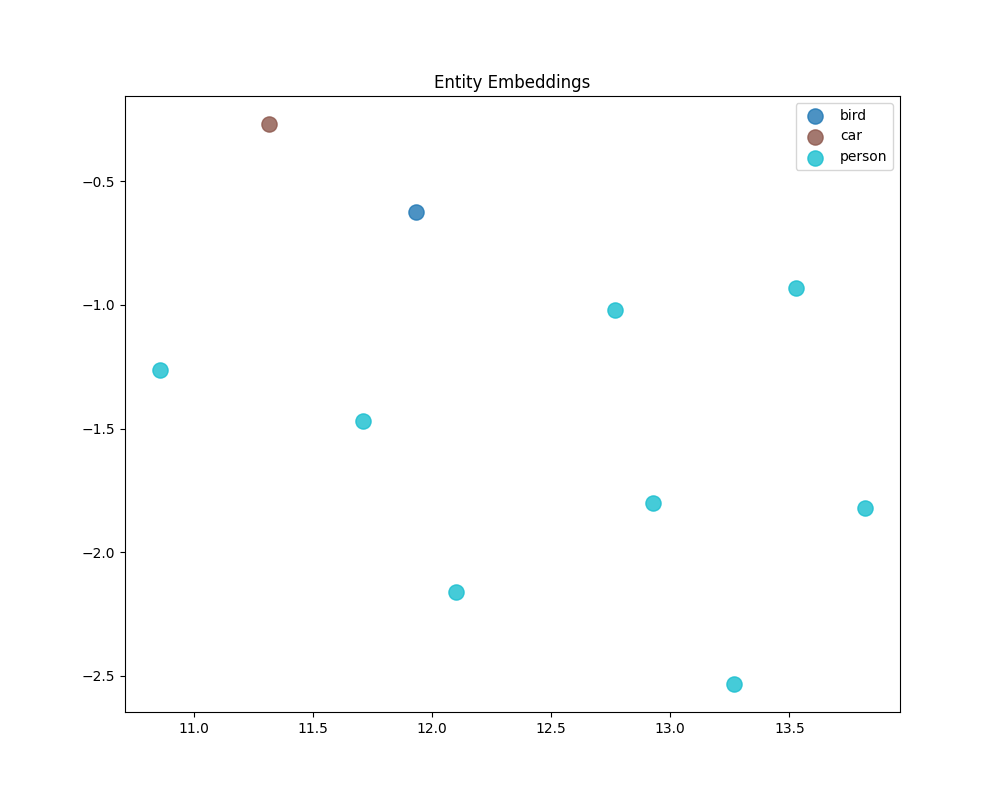

In [18]:
def visualize_entity_embeddings(memory):
    embeddings = []
    labels = []

    for state in memory.get_all_entities(active_only=False):
        embeddings.append(state.embedding_centroid)
        labels.append(state.consensus_label)

    embeddings = np.array(embeddings)

    reduced = umap.UMAP(
        n_components=2,
        metric="cosine"
    ).fit_transform(embeddings)

    unique_labels = list(set(labels))
    colors = plt.cm.tab10(
        np.linspace(0, 1, len(unique_labels))
    )

    fig, ax = plt.subplots(figsize=(10, 8))

    for i, label in enumerate(unique_labels):
        mask = np.array([l == label for l in labels])

        ax.scatter(
            reduced[mask, 0],
            reduced[mask, 1],
            c=[colors[i]],
            label=label,
            s=120,
            alpha=0.8
        )

    ax.legend()
    ax.set_title("Entity Embeddings")
    plt.show()

visualize_entity_embeddings(memory)

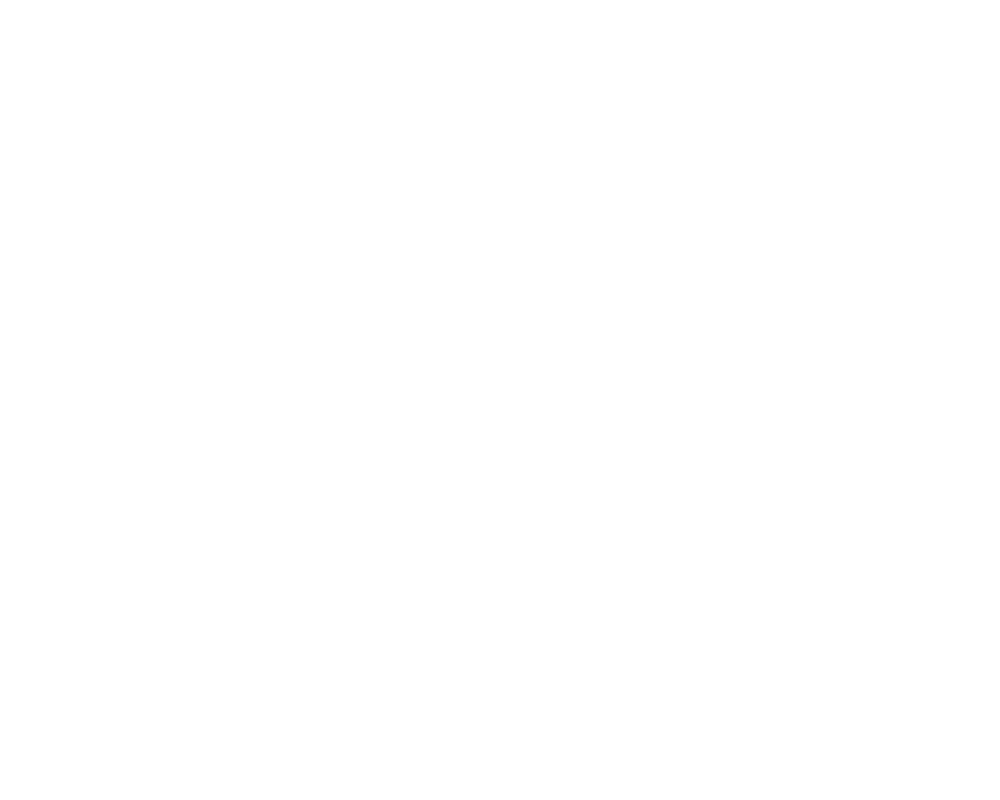

In [19]:
def visualize_spatial_memory(memory):
    import matplotlib.pyplot as plt
    import numpy as np

    fig, ax = plt.subplots(figsize=(10, 8))

    label_colors = {
        "person": "purple",
        "backpack": "orange",
    }

    # ==================================
    # Robot trajectory
    # ==================================

    if len(memory.robot_trajectory) > 0:

        traj = np.array([
            p["pose"][:2]
            for p in memory.robot_trajectory
        ])

        ax.plot(
            traj[:, 0],
            traj[:, 1],
            linewidth=2,
            label="Robot trajectory"
        )

        ax.scatter(
            traj[0, 0],
            traj[0, 1],
            marker="o",
            s=100,
            label="Start"
        )

        ax.scatter(
            traj[-1, 0],
            traj[-1, 1],
            marker="X",
            s=120,
            label="End"
        )

    # ==================================
    # Entity locations
    # ==================================

    entities = memory.get_all_entities(
        active_only=False
    )

    for state in entities:

        x, y = state.consensus_pose[:2]

        ax.scatter(
            x,
            y,
            s=120
        )

        ax.text(
            x,
            y,
            state.consensus_label,
            fontsize=8
        )

    ax.set_title("Spatial Memory Map")
    ax.set_xlabel("X (m)")
    ax.set_ylabel("Y (m)")
    ax.axis("equal")
    ax.legend()

    plt.tight_layout()
    plt.show()

visualize_spatial_memory(memory)

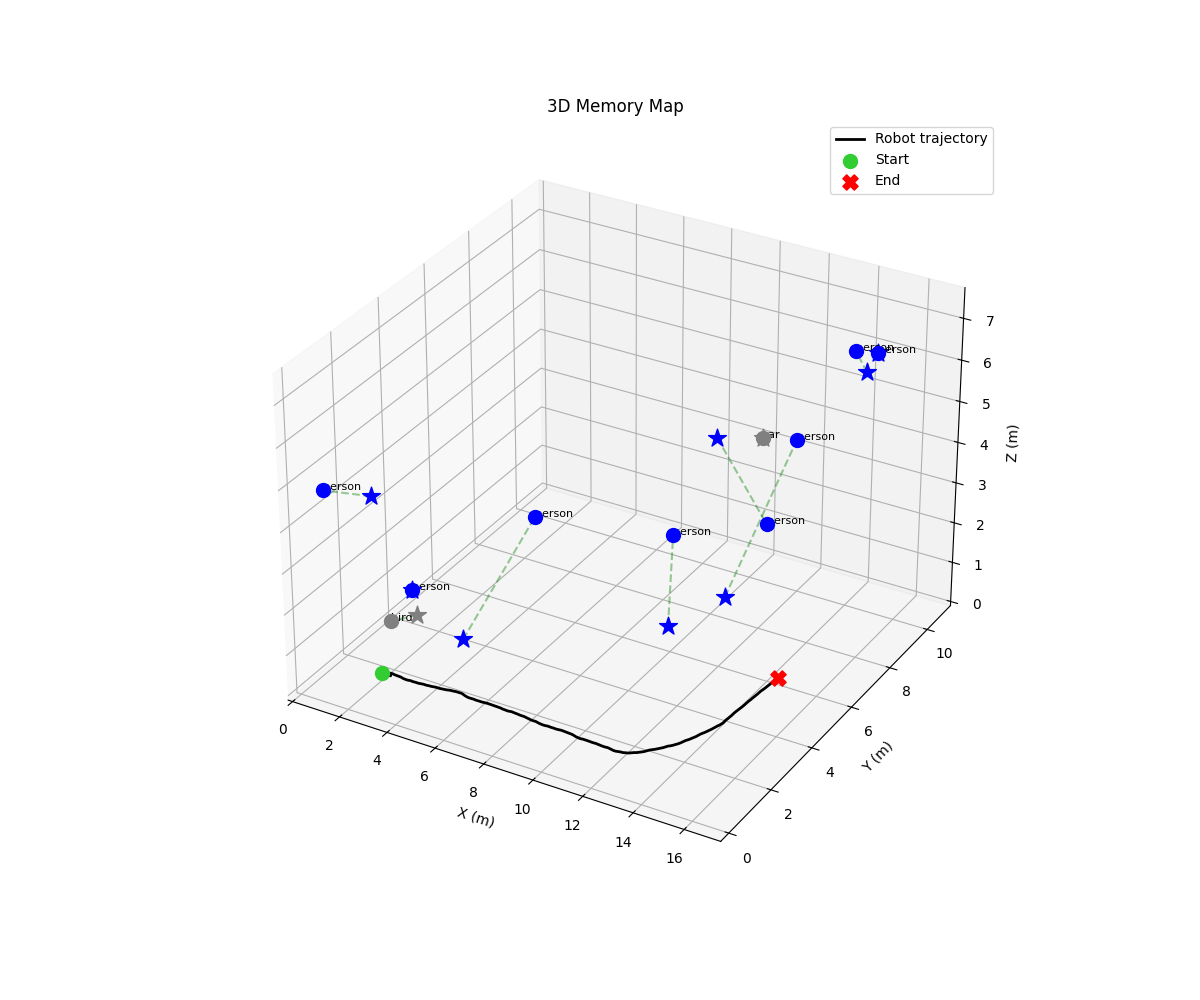

In [20]:
def visualize_spatial_memory_3d(memory):
    import matplotlib.pyplot as plt
    import numpy as np
    from mpl_toolkits.mplot3d import Axes3D

    fig = plt.figure(figsize=(12, 10))
    ax = fig.add_subplot(111, projection="3d")

    label_colors = {
        "person": "blue",
        "backpack": "orange",
    }

    # ==================================================
    # Robot trajectory
    # ==================================================

    if len(memory.robot_trajectory) > 0:

        traj = np.array([
            p["pose"]
            for p in memory.robot_trajectory
        ])

        ax.plot(
            traj[:, 0],
            traj[:, 1],
            traj[:, 2],
            color="black",
            linewidth=2,
            label="Robot trajectory"
        )

        ax.scatter(
            traj[0, 0],
            traj[0, 1],
            traj[0, 2],
            color="limegreen",
            s=100,
            marker="o",
            label="Start"
        )

        ax.scatter(
            traj[-1, 0],
            traj[-1, 1],
            traj[-1, 2],
            color="red",
            s=120,
            marker="X",
            label="End"
        )

    # ==================================================
    # Entities
    # ==================================================

    entities = memory.get_all_entities(
        active_only=False
    )

    for state in entities:

        x, y, z = state.consensus_pose

        color = label_colors.get(
            state.consensus_label,
            "gray"
        )

        ax.scatter(
            x,
            y,
            z,
            color=color,
            s=100
        )

        ax.text(
            x,
            y,
            z,
            state.consensus_label,
            fontsize=8
        )

        # ==========================
        # First observation location
        # ==========================
    
        obs = min(
            (memory._obs[o] for o in state.observations),
            key=lambda x: x.timestamp
        )
    
        fx, fy, fz = obs.pose_3d
    
        ax.scatter(
            fx,
            fy,
            fz,
            color=color,
            marker="*",
            s=180
        )
    
        ax.plot(
            [fx, x],
            [fy, y],
            [fz, z],
            color="green",
            linestyle="--",
            alpha=0.4
        )

    ax.set_title("3D Memory Map")

    ax.set_xlabel("X (m)")
    ax.set_ylabel("Y (m)")
    ax.set_zlabel("Z (m)")

    ax.legend()
    plt.show()

visualize_spatial_memory_3d(memory)

Rendering frame 0


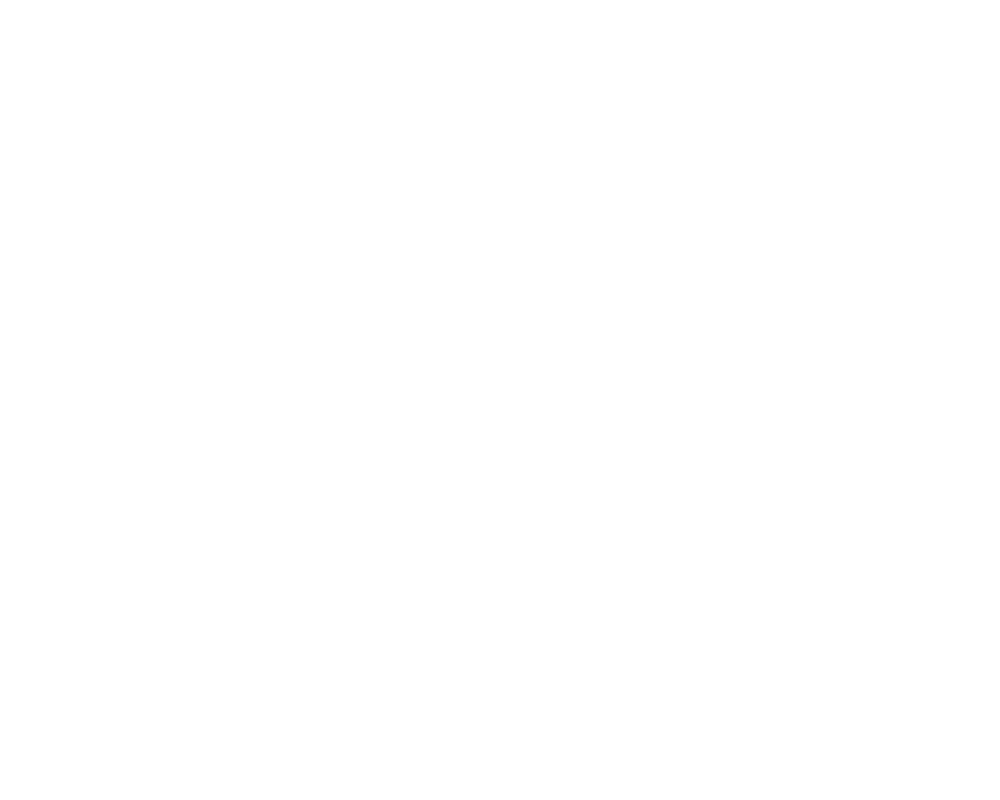

In [21]:
def dedupe_edges(edges):
    seen = set()
    clean = []
    for e in edges:
        # For LLM edges, keep only the highest-weight one per pair
        pair = tuple(sorted([e["src"], e["dst"]]))
        key = (pair, e["type"])
        if key in seen:
            continue
        seen.add(key)
        clean.append(e)
    return clean

def visualize_ontology(memory, recompute_layout_every=10, render_every=30, 
                       output_dir="ontology_frames", save_to_file=False):
    print("Rendering frame", observer.frame_count)

    # ------------------------------------------------------------------
    # 1. Build graph first — before any figure work
    # ------------------------------------------------------------------
    G = nx.Graph()
    entities = memory.get_all_entities(active_only=False)
    edges = dedupe_edges(memory.get_all_edges(active_only=False))

    for e in entities:
        G.add_node(
            e.entity_id,
            label=e.consensus_label,      # semantic label ("person")
            track_id=e.entity_id,                # identity ("ent_88ece27c")
            confidence=e.confidence
    )
    for edge in edges:
        if edge["src"] not in memory._entities or edge["dst"] not in memory._entities:
            continue

        G.add_edge(
            edge["src"],
            edge["dst"],
            type=edge["type"],
            weight=edge["weight"],
        )

    if len(G.nodes) == 0:
        print("No entities to render")
        return

    # ------------------------------------------------------------------
    # 2. Layout
    # ------------------------------------------------------------------
    should_recompute = (
        memory.cached_layout is None
        or observer.frame_count % recompute_layout_every == 0
        or set(memory.cached_layout.keys()) != set(G.nodes)
    )

    if should_recompute:
        if memory.cached_layout is not None and set(memory.cached_layout.keys()) == set(G.nodes):
            memory.cached_layout = nx.spring_layout(
                G, seed=42, iterations=5, pos=memory.cached_layout
            )
        else:
            memory.cached_layout = nx.spring_layout(G, seed=42, iterations=20)

    pos = memory.cached_layout

    # ------------------------------------------------------------------
    # 3. Edge partition
    # ------------------------------------------------------------------
    spatial_edges, semantic_edges, llm_edges = [], [], []
    for u, v, d in G.edges(data=True):
        if d["type"] == "spatial":
            spatial_edges.append((u, v))
        elif d["type"] == "semantic":
            semantic_edges.append((u, v))
        else:  # llm_carrying, llm_following, llm_grouped_with, etc.
            llm_edges.append((u, v))

    # ------------------------------------------------------------------
    # 4. Figure — always fresh to avoid widget conflicts
    # ------------------------------------------------------------------
    plt.close("all")
    fig, ax = plt.subplots(figsize=(10, 8))

    # ------------------------------------------------------------------
    # 5. Draw
    # ------------------------------------------------------------------
    node_colors = [
        "red" if G.nodes[n].get("conflicted", False) else "steelblue"
        for n in G.nodes
    ]

    counter = defaultdict(int)
    
    for n in G.nodes:
        label = G.nodes[n].get("label", "unknown")
        counter[label] += 1
        G.nodes[n]["display_name"] = f"{label}_{counter[label]}"
    
    labels = {n: G.nodes[n]["display_name"] for n in G.nodes}

    nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=700, ax=ax)
    nx.draw_networkx_labels(G, pos, labels=labels, font_size=8, ax=ax)

    if spatial_edges:
        nx.draw_networkx_edges(G, pos, edgelist=spatial_edges,
                               edge_color="gray", width=2, ax=ax)
    if semantic_edges:
        nx.draw_networkx_edges(G, pos, edgelist=semantic_edges,
                               edge_color="orange", style="dashed", width=2, ax=ax)

    if llm_edges:
        nx.draw_networkx_edges(G, pos, edgelist=llm_edges,
                               edge_color="purple", style="dotted", width=2, ax=ax)

    llm_edge_labels = {
        (u, v): d.get("label", d["type"])
        for u, v, d in G.edges(data=True)
        if d["type"].startswith("llm_")
    }

    nx.draw_networkx_edge_labels(
        G,
        pos,
        edge_labels=llm_edge_labels,
        font_size=7,
        ax=ax
    )

    # ------------------------------------------------------------------
    # 6. Legend + title
    # ------------------------------------------------------------------
    from matplotlib.lines import Line2D
    legend = [
        Line2D([0], [0], color="gray",                                    label="Spatial"),
        Line2D([0], [0], color="orange",    linestyle="dashed",           label="Semantic"),
        Line2D([0], [0], color="purple",    linestyle="dotted",            label="LLM relation"),
        Line2D([0], [0], marker="o", color="steelblue", linestyle="None", label="Entity"),
        Line2D([0], [0], marker="o", color="red",       linestyle="None", label="Conflicted"),
    ]
    ax.legend(handles=legend, loc="upper left")
    ax.set_title(f"Ontology Graph — {len(entities)} entities, frame {observer.frame_count}")
    ax.axis("off")

    # ------------------------------------------------------------------
    # 7. Output
    # ------------------------------------------------------------------
    if save_to_file:
        import os
        os.makedirs(output_dir, exist_ok=True)
        path = os.path.join(output_dir, f"frame_{observer.frame_count:05d}.png")
        plt.savefig(path, dpi=80)
        plt.close(fig)
    else:
        plt.tight_layout()
        plt.show()

edges = memory.get_all_edges()

memory.update_relations()
visualize_ontology(memory)

In [22]:
import cv2
import numpy as np
import io

def render_video(
    memory: SceneMemory,
    frame_loader,          # callable: timestamp -> np.ndarray (BGR)
    output_path: str,
    fps: int = 10,
):
    # Sort all observations by timestamp
    obs_by_time = sorted(memory._obs.values(), key=lambda o: o.timestamp)
    
    # Group into frames (observations within 0.1s = same frame)
    frames = defaultdict(list)
    for obs in obs_by_time:
        bucket = round(obs.timestamp * fps) / fps
        frames[bucket].append(obs)
    
    # Get frame dimensions from first frame
    sample_frame = frame_loader(obs_by_time[0].timestamp)
    H, W = sample_frame.shape[:2]
    
    writer = cv2.VideoWriter(
        output_path,
        cv2.VideoWriter_fourcc(*"mp4v"),
        fps, (W, H)
    )
    
    # Color per agent
    agent_colors = {
        "anymal_0": (255, 100, 100),
        "anymal_1": (100, 255, 100),
        "anymal_2": (100, 100, 255),
    }
    
    for t, obs_list in sorted(frames.items()):
        frame = frame_loader(t).copy()
        
        for obs in obs_list:
            if obs.bounding_box is None:
                continue
            
            x1, y1, x2, y2 = [int(v) for v in obs.bounding_box]
            color = agent_colors.get(obs.agent_id, (200, 200, 200))
            
            # Box
            cv2.rectangle(frame, (x1, y1), (x2, y2), color, 2)
            
            # Label + confidence
            state = memory.get_entity_state(obs.entity_id)
            label = state.consensus_label if state else "unknown"
            conf  = state.confidence if state else 0.0
            conf_flag = " ⚠" if (state and state.is_conflicted) else ""
            
            text = f"{label} {conf:.0%}{conf_flag}"
            cv2.putText(frame, text, (x1, y1 - 6),
                       cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 1)
            
            # Entity ID (small, below box)
            cv2.putText(frame, obs.entity_id[:10], (x1, y2 + 14),
                       cv2.FONT_HERSHEY_SIMPLEX, 0.35, color, 1)
        
        # Timestamp overlay
        cv2.putText(frame, f"t={t:.2f}s", (10, 20),
                   cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255,255,255), 1)
        
        writer.write(frame)
    
    writer.release()
    print(f"Video written to {output_path}")

# Build a timestamp -> frame index lookup from zarr
cam_ts_arr = root["alphasense_front_center"]["timestamp"][:]
rgb_tar = tarfile.open(cache_root / "images/alphasense_front_center.tar", "r")
rgb_members = {m.name: m for m in rgb_tar.getmembers() if m.name.endswith(".jpeg")}

def frame_loader(timestamp: float) -> np.ndarray:
    """Given a timestamp, return the nearest RGB frame in BGR (for OpenCV)."""
    idx = int(np.argmin(np.abs(cam_ts_arr - timestamp)))
    fname = f"alphasense_front_center/{idx:06d}.jpeg"
    if fname not in rgb_members:
        # Return blank frame if missing
        return np.zeros((720, 1280, 3), dtype=np.uint8)
    img_bytes = rgb_tar.extractfile(rgb_members[fname]).read()
    rgb = np.array(Image.open(io.BytesIO(img_bytes)).convert("RGB"))
    return cv2.cvtColor(rgb, cv2.COLOR_RGB2BGR)  # OpenCV expects BGR

render_video(
    memory=memory,
    frame_loader=frame_loader,
    output_path="output_video.mp4",
    fps=10,
)

Video written to output_video.mp4


In [23]:
entities = memory.get_all_entities()

print("Total entities:", len(entities))

from collections import Counter

label_counts = Counter(
    e.consensus_label for e in entities
)

for label, count in label_counts.most_common():
    print(label, count)

Total entities: 10
person 8
car 1
bird 1


In [24]:
entities = memory.get_all_entities()

people = [
    e for e in entities
    if "person" in e.consensus_label.lower()
]

print("People entities:", len(people))

for e in people[:20]:
    print(
        e.entity_id,
        e.consensus_label,
        getattr(e, "track_id", None)
    )

People entities: 8
ent_dac4e264 person None
ent_648f36db person None
ent_8256f7ba person None
ent_91dcbafb person None
ent_36f65c2e person None
ent_cd7f035c person None
ent_800d1f17 person None
ent_7daa3b9e person None
